# Objaverse asset explorer

Find, evaluate and import Objaverse assets for the scene generator's asset sets.

The generator references USDs; Objaverse ships glb. `utils/objaverse_assets.py` bridges
that (search -> download -> convert -> manifest). This notebook is the *evaluation*
front-end: metadata filtering is cheap, but whether an asset actually **looks** like a
suburban house is something you have to see, so we render candidates before importing.

In [4]:
# Offscreen GPU rendering — must be set before pyrender is imported anywhere.
import os
os.environ["PYOPENGL_PLATFORM"] = "egl"

import sys
import numpy as np

# The kernel's cwd is the Jupyter server root, not this file's directory, so
# anchor on the repo layout rather than a relative hop.
def _find_scene_gen(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        cand = os.path.join(d, "scene_gen")
        if os.path.isdir(cand):
            return cand
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("could not locate scene_gen/")
        d = parent

SCENE_GEN = _find_scene_gen()
sys.path.insert(0, SCENE_GEN)

import importlib
import objaverse_assets as oa
# This notebook and the library are developed together; reload so an edit to
# objaverse_assets.py takes effect without discarding the loaded catalog.
importlib.reload(oa)

catalog = oa.load_catalog(quiet=True)
print(f"catalog: {len(catalog):,} Objaverse 1.0 objects")
print(f"assets land in: {oa.ASSET_DIR}")

# How much of the dataset is even usable: the generator needs textured,
# unanimated, reasonably-sized meshes.
usable = oa.search(catalog, "")
print(f"textured + unanimated + <=400k faces: {len(usable):,} "
      f"({len(usable) / len(catalog) * 100:.1f}%)")

catalog: 798,759 Objaverse 1.0 objects
assets land in: /home/myan2/coasei/AirStack/scene_gen/assets/objaverse


textured + unanimated + <=400k faces: 397,189 (49.7%)


In [5]:
# Suburban houses: detached single-family homes.
#
# Keyword recall is the easy part; precision is the problem. "house" drags in
# interiors, dollhouses, housing estates and furniture, so the exclude list
# does most of the work. `search` word-boundaries bare terms, which already
# kills warehouse/greenhouse/lighthouse (no boundary before "house").
HOUSE = r"house|cottage|bungalow|villa|townhouse|suburban|residential home"
NOT_HOUSE = (
    r"interior|room|kitchen|bathroom|bedroom|living|furniture|sofa|chair|table|"
    r"apartment|skyscraper|tower|castle|church|temple|palace|mansion|"
    r"housing|estate|city|street|block|"          # multi-building scenes
    r"minecraft|voxel|cartoon|anime|character|weapon|"
    r"ruin|abandoned|destroyed|burnt|"            # the generator damages assets itself
    r"plan|floorplan|blueprint|section|diagram"
)

houses = oa.search(
    catalog, HOUSE, exclude=NOT_HOUSE,
    min_textures=1,
    min_texture_res=1024,    # 512-and-below reads as mush at drone altitude
    min_faces=2_000,         # below this it's a shoebox with a roof
    max_faces=300_000,
    sort="likes", limit=40,
)

print(f"{len(oa.search(catalog, HOUSE, exclude=NOT_HOUSE, min_textures=1, min_texture_res=1024, min_faces=2000, max_faces=300_000)):,} candidates\n")
houses[["uid", "name", "faces", "textures", "texture_res", "license", "likes"]].head(25)

3,449 candidates



,uid,name,faces,textures,texture_res,license,likes
424795,52429e4ef7bf4deda1309364a2cda86f,Forest House,21518,12,2048,by-nc,2187
218205,0772aec70d584c60a27000af5f6c1ef4,Painterly Cottage,6602,3,2048,by-nc,1586
104012,494788a17a7e4c6d9ea62b43e2730607,Tree House,37964,21,2048,by,1286
161281,a0d3931586a14385b6617cf7160aaa47,Post-Apocalyptic | House | Dirty | Old | Wooden,7952,18,4096,by,1145
308031,f44115f33e954c75828d09cce03a729a,DraftPunk HW#9: Auto-Mapping (Aze K),117941,21,2048,by,783
366718,52772448c62348e0a4951b51758d5587,Autumn House,7991,5,2048,by,783
613335,d537595db4bf4a60b955b31cde198432,Russian panel house (asset),34569,36,1024,by,754
791288,d2716e8b42744846aeafc91c591c9425,tbp,72426,5,4096,by-nc-sa,614
225908,a4ba41df514e447095c2106f85734093,Low | House | Building | Apocalypse | Dirty,2407,16,2048,by,614
37069,19a1121bab5a4aaaad4d973abe5b61cb,Old house,3821,12,4096,by,511


In [6]:
import math
import trimesh
import pyrender
import matplotlib.pyplot as plt
from PIL import Image

# Objaverse glb are Y-up, which is also pyrender's convention, so meshes render
# upright with no correction. (The USD conversion is what rotates to Z-up.)

def _look_at(eye, target=(0, 0, 0), up=(0, 1, 0)):
    eye, target = np.asarray(eye, float), np.asarray(target, float)
    fwd = target - eye; fwd /= np.linalg.norm(fwd)
    right = np.cross(fwd, up); right /= np.linalg.norm(right)
    pose = np.eye(4)
    pose[:3, 0], pose[:3, 1], pose[:3, 2], pose[:3, 3] = right, np.cross(right, fwd), -fwd, eye
    return pose


def _to_pyrender_scene(tm):
    """Build a pyrender scene from a trimesh scene, honoring the transform graph.

    `pyrender.Scene.from_trimesh_scene` raises on any non-mesh geometry, and a
    fair number of Objaverse glbs carry `Path3D` curves next to their meshes —
    which would otherwise look like a bad asset rather than a bad loader.
    """
    scene = pyrender.Scene(bg_color=[0.10, 0.11, 0.13, 1.0],
                           ambient_light=[0.35, 0.35, 0.38])
    for name in tm.graph.nodes_geometry:
        pose, geom_name = tm.graph[name]
        geom = tm.geometry[geom_name]
        if not isinstance(geom, trimesh.Trimesh) or not len(geom.faces):
            continue
        scene.add(pyrender.Mesh.from_trimesh(geom, smooth=False), pose=pose)
    if not scene.meshes:
        raise ValueError("no triangle geometry")
    return scene


def render_glb(path, res=384, azim=40.0, elev=22.0, dist=2.3):
    """Render a glb from a 3/4 view with its own materials/textures.

    Textures are the whole point of the filter, so this renders the real
    material rather than a clay override — an asset whose texture is a flat
    grey or an untextured UV mess is exactly what we're trying to catch.
    """
    tm = trimesh.load(path, force="scene")
    scene = _to_pyrender_scene(tm)

    # Frame the whole model: normalize by its bounding sphere.
    lo, hi = tm.bounds
    center = (lo + hi) / 2.0
    radius = float(np.linalg.norm(hi - lo)) / 2.0 or 1.0

    a, e = math.radians(azim), math.radians(elev)
    eye = center + radius * dist * np.array(
        [math.cos(e) * math.sin(a), math.sin(e), math.cos(e) * math.cos(a)])
    cam_pose = _look_at(eye, center)
    scene.add(pyrender.PerspectiveCamera(yfov=np.pi / 4.0, znear=radius * 0.01,
                                         zfar=radius * 100), pose=cam_pose)
    # Key light on the camera plus a fill, so roof planes separate from walls.
    scene.add(pyrender.DirectionalLight(color=[1, 1, 1], intensity=4.0), pose=cam_pose)
    scene.add(pyrender.DirectionalLight(color=[1, 1, 1], intensity=2.0),
              pose=_look_at(center + radius * dist * np.array([-0.7, 0.9, -0.5]), center))

    r = pyrender.OffscreenRenderer(res, res)
    try:
        color, _ = r.render(scene)
    finally:
        r.delete()
    return Image.fromarray(color)


def contact_sheet(items, cols=5, res=384, title=None):
    """items: list of (label, glb path). Renders a labelled grid; failures are
    reported inline instead of aborting the batch."""
    n = len(items)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.3 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, (label, path) in zip(axes, items):
        try:
            ax.imshow(render_glb(path, res=res))
            ax.set_title(label, fontsize=7.5)
        except Exception as exc:
            ax.set_title(f"{label}\nFAILED: {type(exc).__name__}", fontsize=7, color="crimson")
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


def texture_report(path):
    """Is an asset actually textured, or does it just declare textures?

    Sketchfab's `textureCount` counts images in the archive, which does not
    mean the materials sample them — several candidates render flat grey
    despite a non-zero count. This checks the materials as loaded.
    """
    tm = trimesh.load(path, force="scene")
    textured = plain = 0
    for geom in tm.geometry.values():
        if not isinstance(geom, trimesh.Trimesh):
            continue
        vis = getattr(geom, "visual", None)
        img = getattr(getattr(vis, "material", None), "baseColorTexture", None)
        if img is None:
            img = getattr(getattr(vis, "material", None), "image", None)
        if img is not None:
            textured += 1
        else:
            plain += 1
    return {"textured_meshes": textured, "untextured_meshes": plain}


def preview(df, n=15, cols=5, res=384, title=None):
    """Download the first *n* rows and render them. Objaverse caches under
    ~/.objaverse, so re-previewing a set you've already pulled is instant."""
    rows = df.head(n)
    paths = oa.download(rows["uid"].tolist(), processes=8)
    items = [(f"{r['name'][:26]}\n{r.uid[:8]}  {int(r.faces or 0):,}f", paths[r.uid])
             for _, r in rows.iterrows() if r.uid in paths]
    print(f"downloaded {len(items)}/{len(rows)}")
    contact_sheet(items, cols=cols, res=res, title=title)
    return {r.uid: paths[r.uid] for _, r in rows.iterrows() if r.uid in paths}


# Smoke-test the EGL context before relying on it for a whole batch.
_probe = pyrender.OffscreenRenderer(64, 64)
_probe.delete()
print("EGL offscreen renderer OK")

EGL offscreen renderer OK


starting download of 15 objects with 8 processes


Downloaded

1

/

15

...

15

/

15

objects

downloaded 15/15


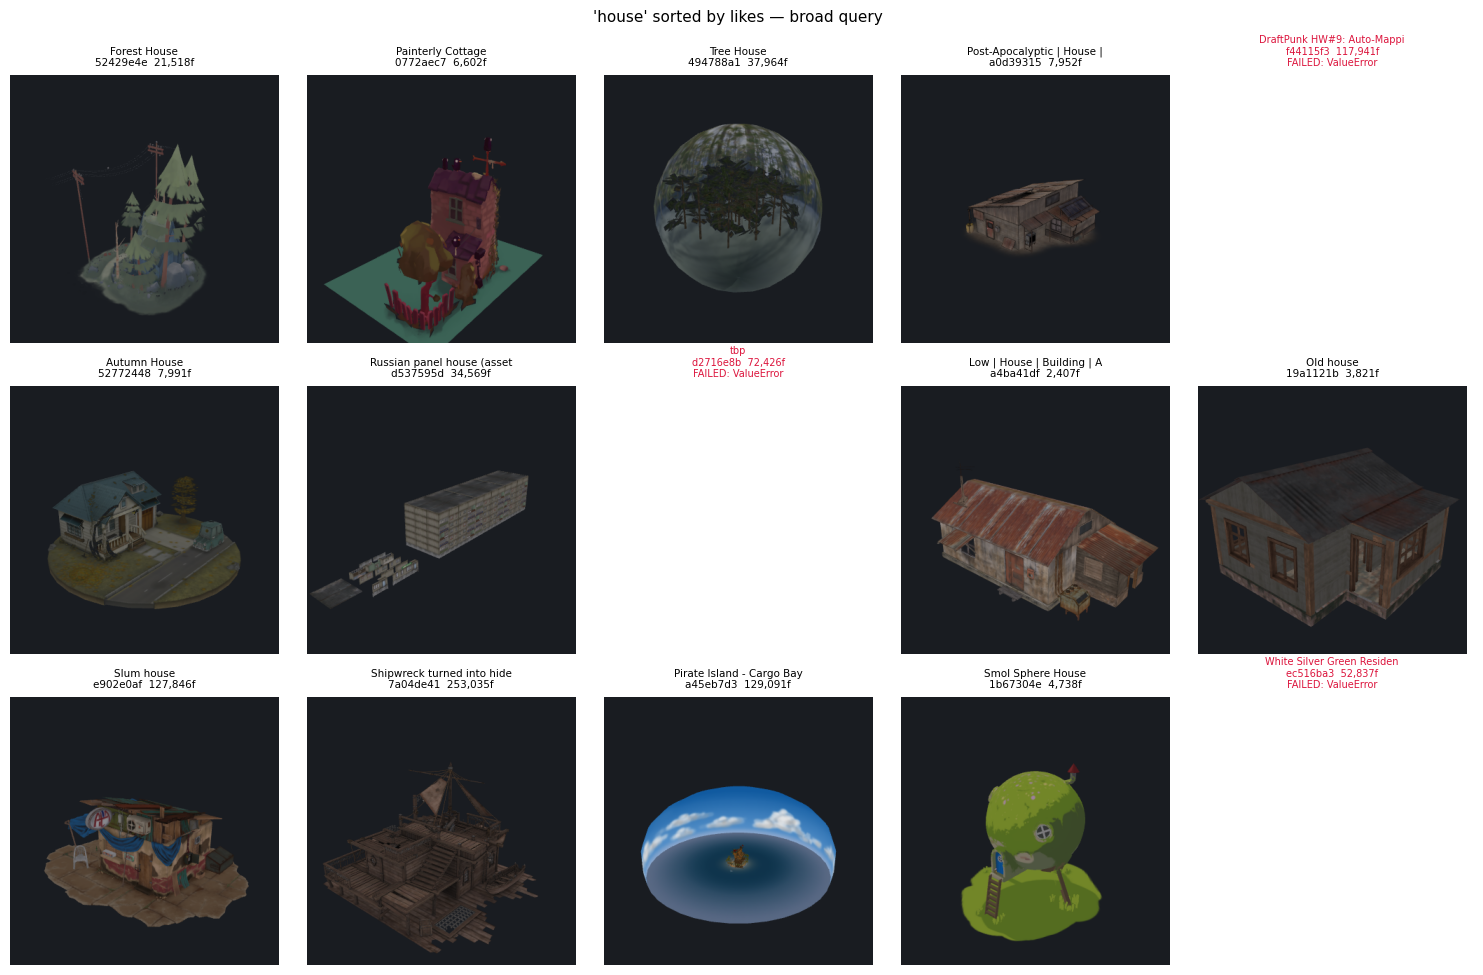

In [5]:
pool = preview(houses, n=15, title="'house' sorted by likes — broad query")

211 suburban candidates


downloaded 15/15


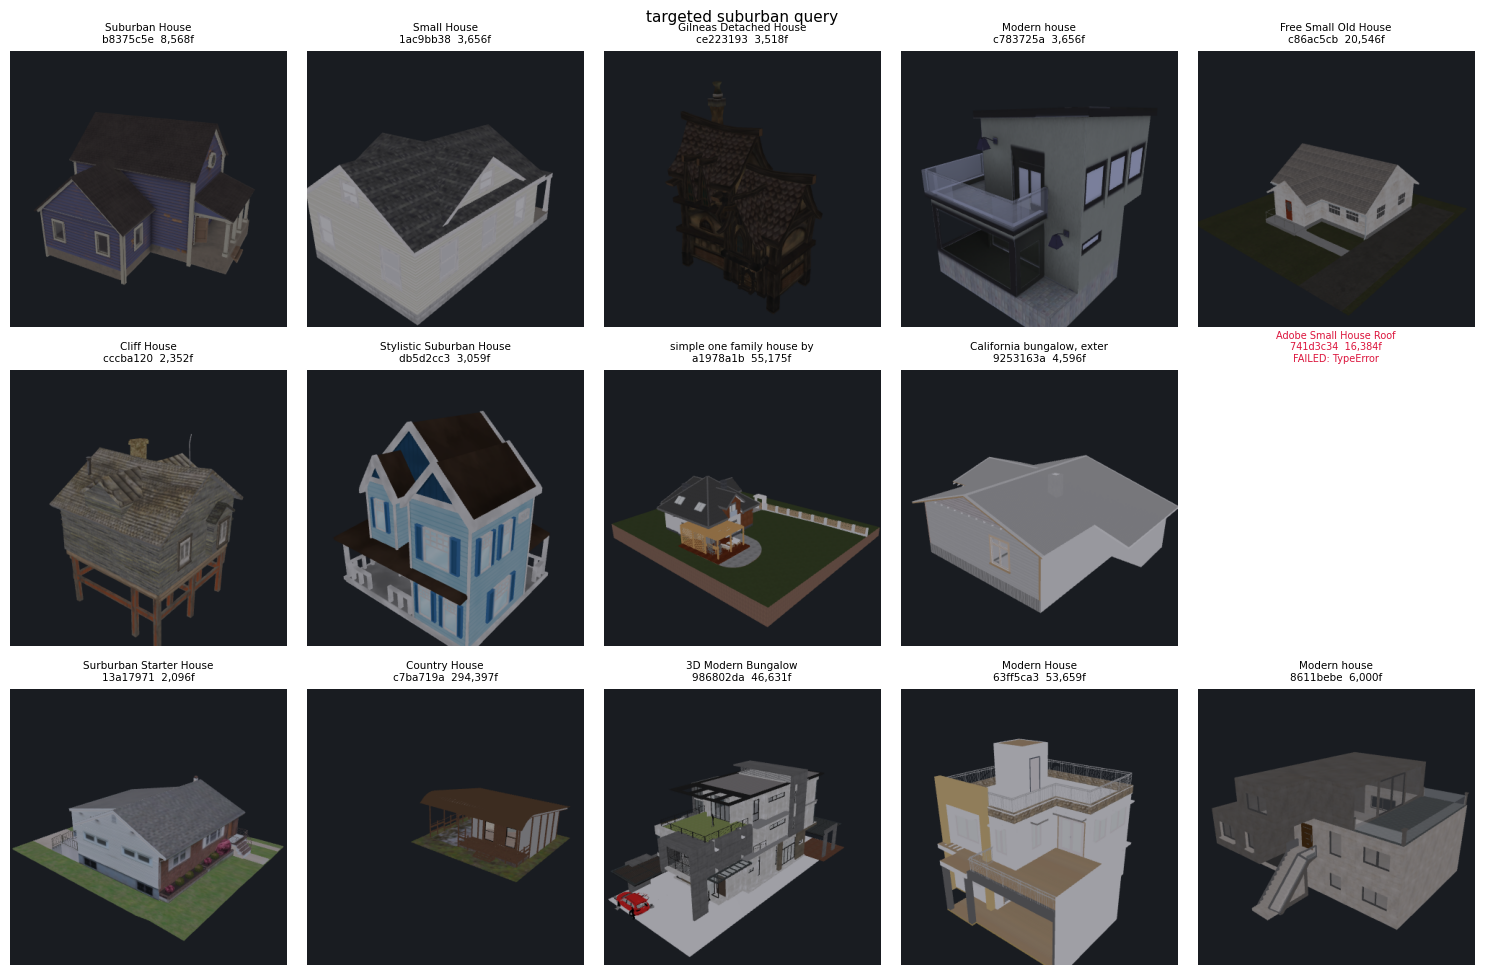

In [7]:
# What the first pass taught us — the failure modes are all *shape*, not metadata:
#   * dioramas: a house sitting on a modelled terrain disc (would import a
#     ground plate into the scene and float above the generator's own ground)
#   * photogrammetry scans wrapped in a sky sphere / panorama dome
#   * shacks, slums, post-apocalyptic ruins — the generator applies its own
#     damage, so it wants intact houses
#   * fantasy/medieval/stylised cottages
#
# So: aim the query at contemporary detached housing and reject scene-like art.
SUBURB = (r"suburban house|suburban home|family house|family home|modern house|"
          r"residential house|detached house|two story house|small house|"
          r"simple house|country house|house exterior|home exterior|bungalow")
NOT_SUBURB = (
    r"interior|room|kitchen|bathroom|bedroom|living|furniture|sofa|chair|"
    r"apartment|skyscraper|tower|castle|church|temple|palace|"
    r"housing|estate|city|street|neighborhood|block|village|town|"
    r"minecraft|voxel|cartoon|anime|character|weapon|lowpoly|low poly|"
    r"ruin|abandoned|destroyed|burnt|slum|shack|hut|apocalyp|zombie|horror|haunted|"
    r"medieval|fantasy|viking|japanese|traditional|"
    r"island|forest|tree|terrain|landscape|diorama|scene|environment|"
    r"panorama|sphere|dome|photogrammetry|scan|"
    r"plan|floorplan|blueprint|section|diagram"
)

sub = oa.search(catalog, SUBURB, exclude=NOT_SUBURB,
                min_textures=1, min_texture_res=1024,
                min_faces=2_000, max_faces=300_000,
                sort="likes")
print(f"{len(sub):,} suburban candidates")
pool2 = preview(sub, n=15, title="targeted suburban query")

name                                 uid         meta  real  plain
Suburban House                       b8375c5e      14     5      1
Small House                          1ac9bb38       7     5      4
Gilneas Detached House               ce223193      15    16      1
Modern house                         c783725a       5     1      0
Free Small Old House                 c86ac5cb      24    10      2
Cliff House                          cccba120       3     1      0
Stylistic Suburban House             db5d2cc3       3     7      0
simple one family house by Kris Sz   a1978a1b      17    17      9
California bungalow, exterior        9253163a       9     9     11
Adobe Small House Roof               741d3c34       3     1      0
Surburban Starter House              13a17971       2     3      0
Country House                        c7ba719a      27    14      7
3D Modern Bungalow                   986802da       9    46    853
Modern House                         63ff5ca3       5     5   

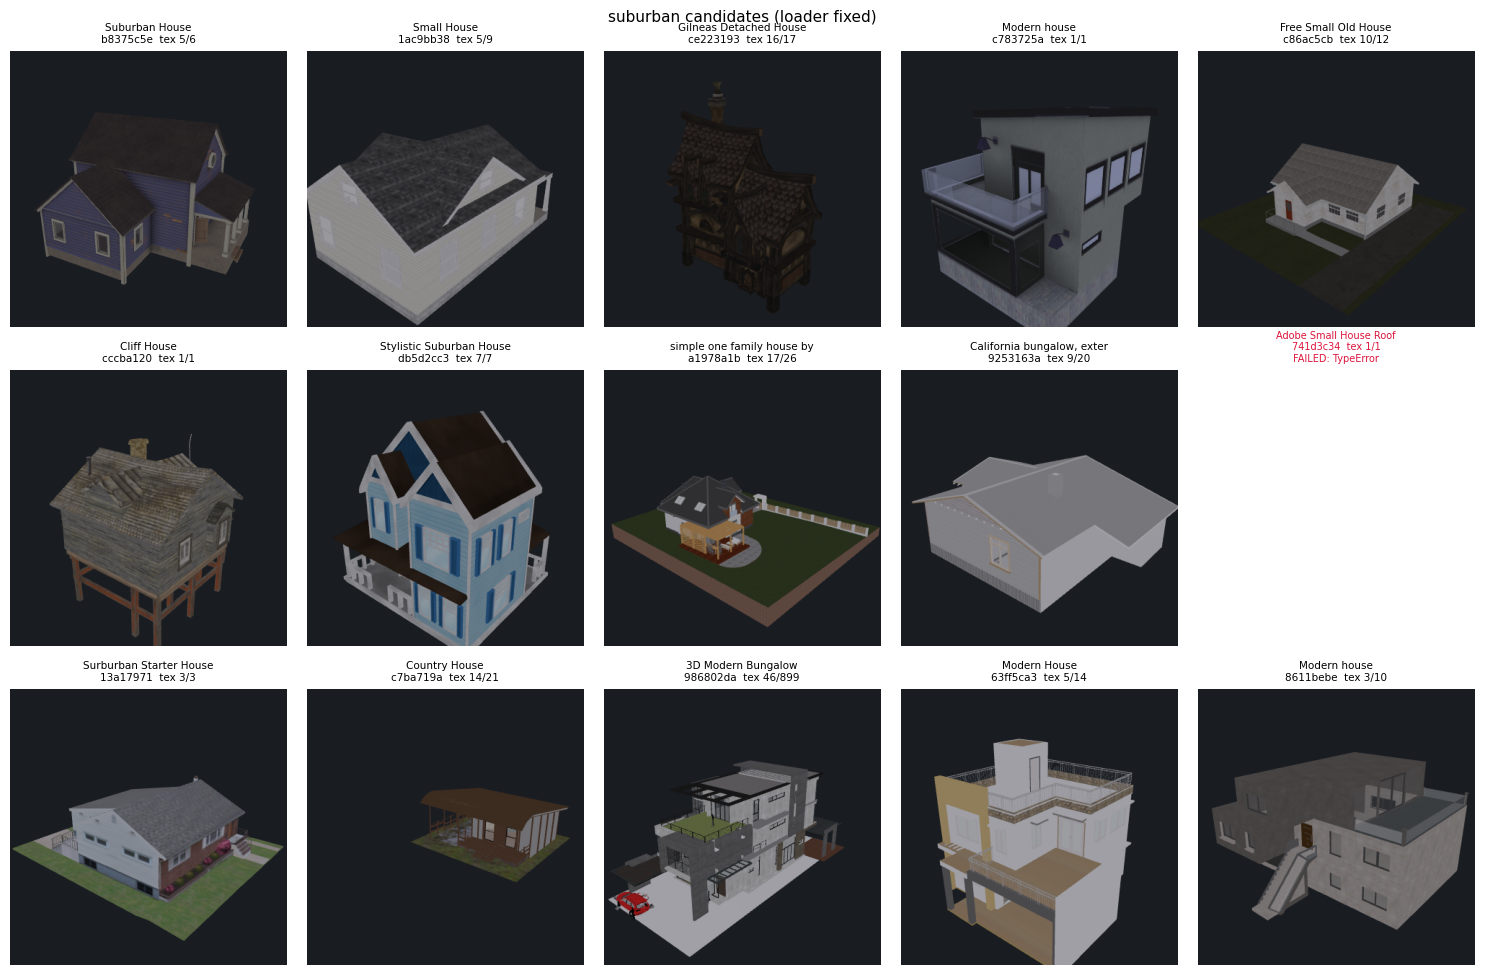

In [7]:
# Audit which candidates are *really* textured. `textureCount` from Sketchfab
# counts images in the archive, not whether the materials sample them — that
# gap is why several of these render flat grey despite a healthy count, and
# why the metadata filter alone can't be trusted.
#
# (`_to_pyrender_scene` above matters here too: pyrender's own scene builder
# raises on the `Path3D` curves several of these glbs carry, which would show
# up as a failed asset rather than a failed loader.)
rows = sub.head(15)
items, report = [], []
for _, r in rows.iterrows():
    p = pool2.get(r.uid)
    if not p:
        continue
    try:
        tr = texture_report(p)
    except Exception as exc:
        tr = {"textured_meshes": -1, "untextured_meshes": -1}
    report.append((r["name"][:34], r.uid[:8], int(r.textures or 0),
                   tr["textured_meshes"], tr["untextured_meshes"]))
    items.append((f"{r['name'][:26]}\n{r.uid[:8]}  tex {tr['textured_meshes']}/"
                  f"{tr['textured_meshes'] + tr['untextured_meshes']}", p))

print(f"{'name':36s} {'uid':10s} {'meta':>5s} {'real':>5s} {'plain':>6s}")
for n, u, meta, t, pl in report:
    flag = "  <- declares textures but has none" if meta and t == 0 else ""
    print(f"{n:36s} {u:10s} {meta:5d} {t:5d} {pl:6d}{flag}")

contact_sheet(items, title="suburban candidates — textured mesh count per asset")

downloaded 20/20


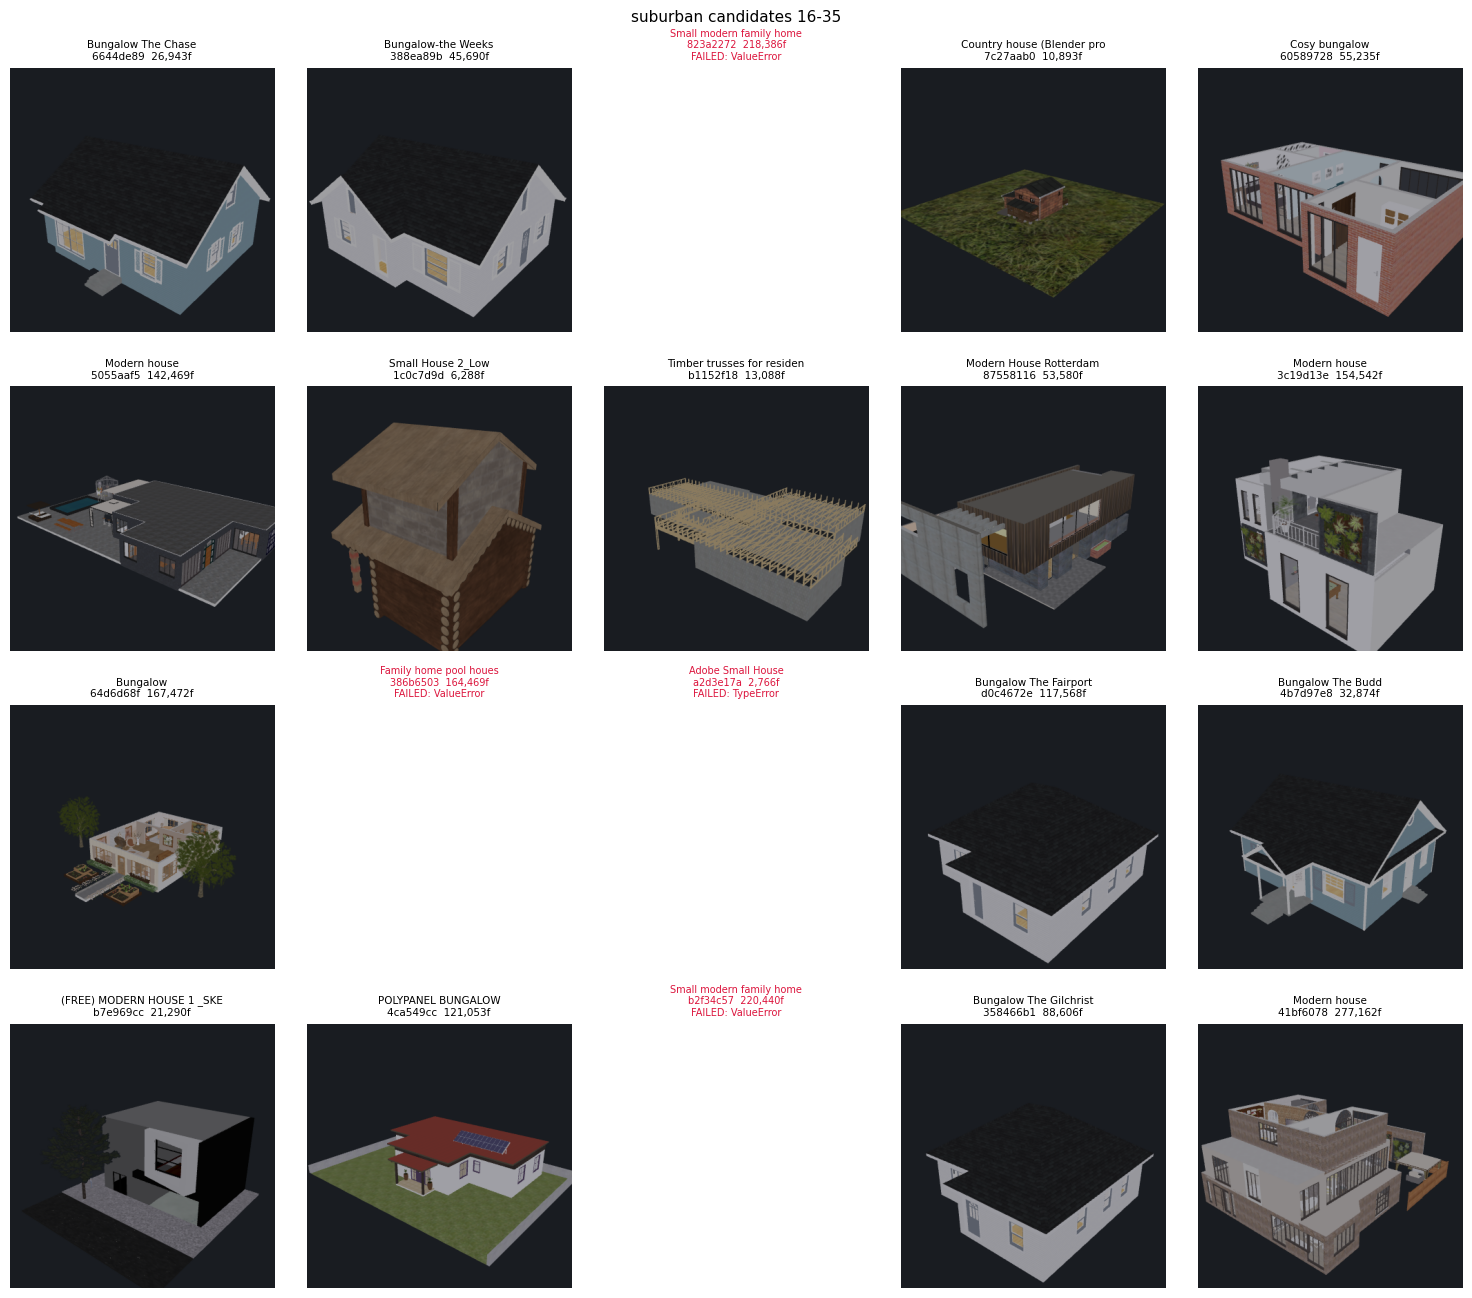

In [8]:
# Deeper into the ranking — the first 15 gave ~5 usable, so look at the next 20.
# Watch for the recurring disqualifier: a modelled ground/lawn plate under the
# house. The generator lays its own ground and snaps assets to it, so a built-in
# base either z-fights with the terrain or leaves the house on a floating slab.
pool3 = preview(sub.iloc[15:35], n=20, title="suburban candidates 16-35")

22 assets in the bungalow family

6644de89c2f0449db3de934744162b63  Bungalow The Chase          26,943f  by
388ea89b91524e4eb79068c24d170619  Bungalow-the Weeks          45,690f  by
d0c4672e5fd14e21a6e244ce39246f57  Bungalow The Fairport      117,568f  by
4b7d97e8a74248c79f4704e1967c3577  Bungalow The Budd           32,874f  by
358466b1877b4947aee36a50662d633b  Bungalow The Gilchrist      88,606f  by


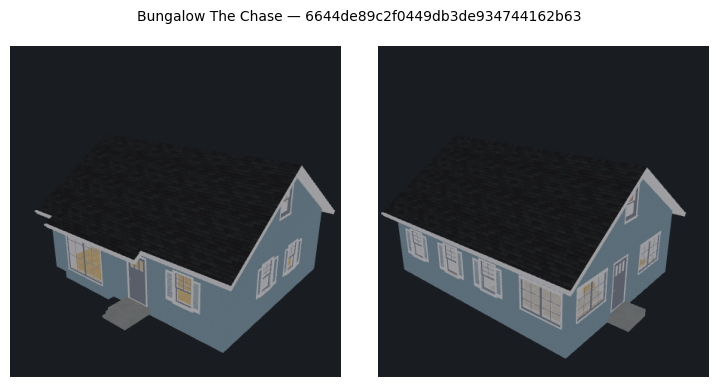

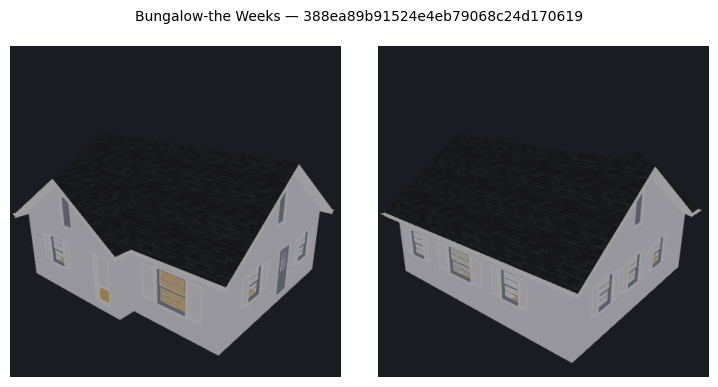

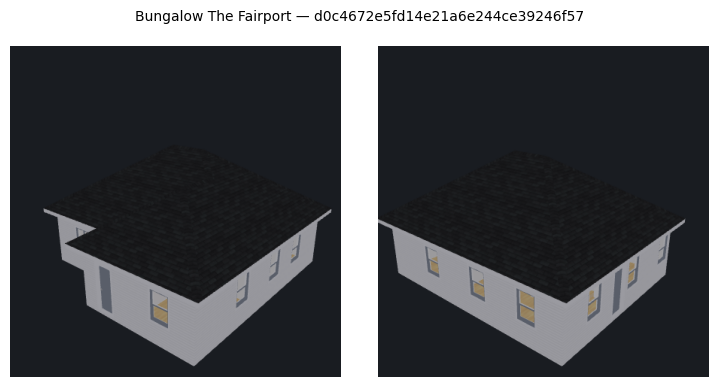

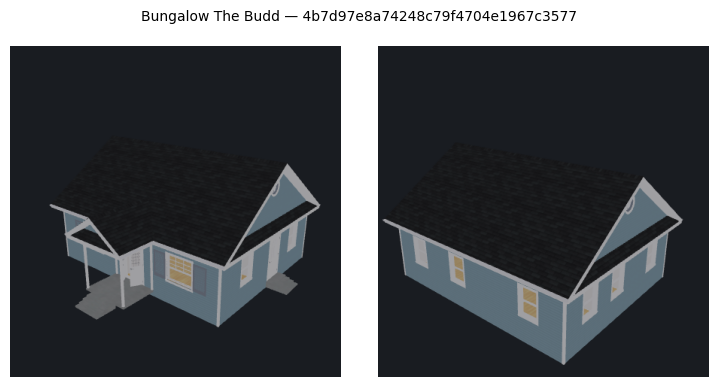

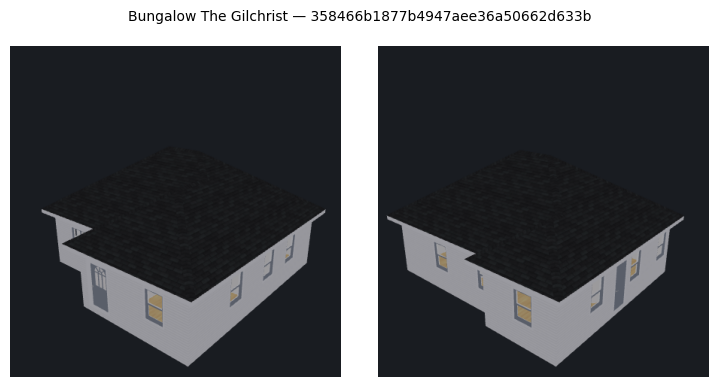

In [8]:
# The "Bungalow The <name>" family is the find: 20+ detached single-family
# houses, one consistent art direction, distinct rooflines and footprints,
# siding + shingle textures at 1024, all CC-BY, and — critically — no modelled
# ground plate. Consistency matters for a neighborhood (five unrelated art
# styles on one street looks wrong) while the varied massing keeps it from
# reading as copy-paste.
#
# Resolve uids by name from the catalog rather than transcribing them.
fam = sub[sub["name"].str.contains(r"bungalow", case=False, na=False)]
fam = fam[fam["name"].str.contains(r"the ", case=False, na=False)]
print(f"{len(fam)} assets in the bungalow family\n")

WANT = ["Bungalow The Chase", "Bungalow-the Weeks", "Bungalow The Fairport",
        "Bungalow The Budd", "Bungalow The Gilchrist"]

chosen = (fam.set_index("name").loc[WANT].reset_index())
# Assets are identified by their Objaverse uid — that is what an asset set
# references and what the local cache is keyed on, so there is no local name
# to invent here.
SELECTION = list(chosen.uid)
for _, row in chosen.iterrows():
    print(f"{row.uid}  {row['name']:26s} {int(row.faces):>7,}f  {row.license}")

# Two angles each, larger — front-left and rear-right, to catch missing back
# walls (common in game art authored for a fixed camera).
paths = oa.download(SELECTION, processes=5)
for uid in SELECTION:
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.9))
    for ax, az in zip(axes, (40, 220)):
        ax.imshow(render_glb(paths[uid], res=440, azim=az, elev=20))
        ax.axis("off")
    fig.suptitle(f"{chosen[chosen.uid == uid].iloc[0]['name']} — {uid}", fontsize=10)
    plt.tight_layout()
    plt.show()

downloaded 6/6


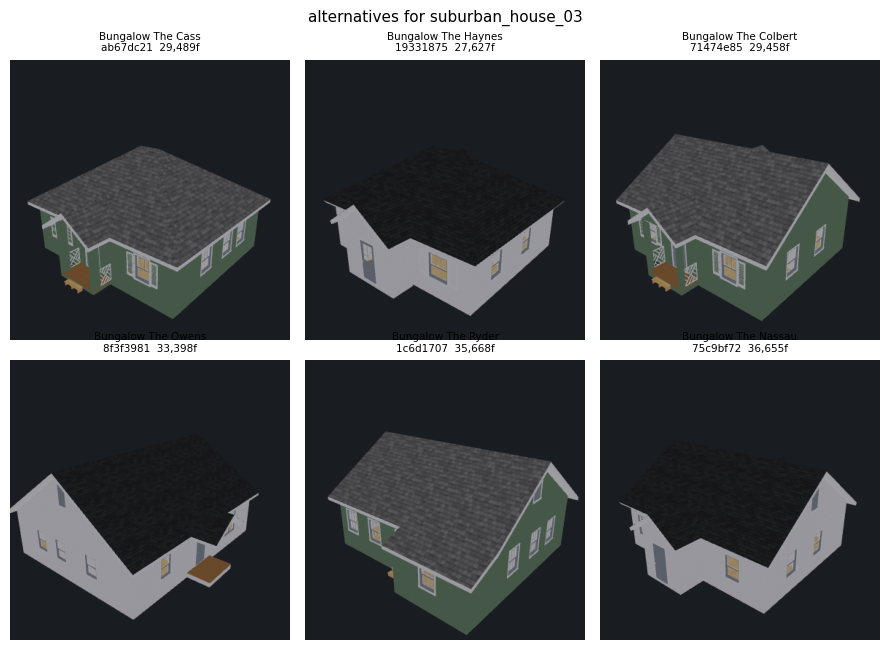

In [10]:
# Fairport (117k faces) and Gilchrist (89k) are near-duplicate hip-roof boxes —
# paying double the polygons for a near-identical silhouette is a bad trade in
# a scene that instances hundreds of buildings. Look for a more distinct,
# cheaper third house.
alts = fam[fam["name"].isin(["Bungalow The Cass", "Bungalow The Haynes",
                             "Bungalow The Ryder", "Bungalow The Colbert",
                             "Bungalow The Owens", "Bungalow The Nassau"])]
_ = preview(alts, n=6, cols=3, title="alternatives for suburban_house_03")

In [9]:
# Ryder wins the slot: a distinct cross-gable silhouette in a different colour,
# for 35.7k faces against Fairport's 117.6k.
SELECTION[2] = fam[fam["name"] == "Bungalow The Ryder"].iloc[0].uid

for uid in SELECTION:
    r = catalog[catalog.uid == uid].iloc[0]
    print(f"{uid}  {r['name']:24s} {int(r.faces):>7,}f  {r.license}")

6644de89c2f0449db3de934744162b63  Bungalow The Chase        26,943f  by
388ea89b91524e4eb79068c24d170619  Bungalow-the Weeks        45,690f  by
1c6d17070d9e4b6595e5de2fa3e20d81  Bungalow The Ryder        35,668f  by
4b7d97e8a74248c79f4704e1967c3577  Bungalow The Budd         32,874f  by
358466b1877b4947aee36a50662d633b  Bungalow The Gilchrist    88,606f  by


In [10]:
# Cache them: download -> Blender/USD conversion (materials + textures preserved)
# -> measure -> record in assets/objaverse/manifest.yaml, keyed by uid.
#
# glb carries no canonical unit, so the metric scale is baked into the USD at
# conversion. A detached suburban house is ~12 m across its long plan
# dimension; `fit="footprint"` pins max(x, y) because a house is sized by its
# plan, not its ridge height.
#
# `ensure` is idempotent — already-cached assets at the same target size are a
# no-op, which is what makes it safe for `airstack up` to call on every launch.
TARGET_FOOTPRINT_M = 12.0

entries = {uid: oa.ensure(uid, target_size_m=TARGET_FOOTPRINT_M,
                          fit="footprint", catalog=catalog)
           for uid in SELECTION}

In [11]:
# Verify the conversion produced what the generator needs: a USD, its textures
# alongside it, and a real-world size already in meters (no scale for a config
# to re-apply).
import glob

for uid, e in sorted(entries.items(), key=lambda kv: kv[1].get("title", "")):
    usd = oa.cache_path(uid)
    tex = glob.glob(os.path.join(os.path.dirname(usd), "textures", "*"))
    mb = os.path.getsize(usd) / 1e6
    texmb = sum(os.path.getsize(t) for t in tex) / 1e6
    print(f"{uid}  {mb:5.1f} MB usd  {len(tex):2d} tex ({texmb:4.1f} MB)  "
          f"{e['size_m'][0]:.1f} x {e['size_m'][1]:.1f} x {e['size_m'][2]:.1f} m  "
          f"{e['license']}  {e['title']}")

print("\n--- paste into an asset set ---")
print(oa.asset_set_entries(entries.keys()))

4b7d97e8a74248c79f4704e1967c3577    2.4 MB usd   7 tex ( 1.5 MB)  12.0 x 12.0 x 6.3 m  by  Bungalow The Budd
6644de89c2f0449db3de934744162b63    2.0 MB usd  10 tex ( 1.6 MB)  12.0 x 10.6 x 6.4 m  by  Bungalow The Chase
358466b1877b4947aee36a50662d633b    6.0 MB usd   7 tex ( 1.5 MB)  11.4 x 12.0 x 6.3 m  by  Bungalow The Gilchrist
1c6d17070d9e4b6595e5de2fa3e20d81    2.6 MB usd   8 tex ( 1.0 MB)  12.0 x 11.2 x 6.6 m  by  Bungalow The Ryder
388ea89b91524e4eb79068c24d170619    3.4 MB usd   9 tex ( 1.6 MB)  12.0 x 10.8 x 6.6 m  by  Bungalow-the Weeks

--- paste into an asset set ---
      - usd: "objaverse://4b7d97e8a74248c79f4704e1967c3577"
        target-size-m: 12   # Bungalow The Budd — 11.976x12.0x6.325 m
      - usd: "objaverse://6644de89c2f0449db3de934744162b63"
        target-size-m: 12   # Bungalow The Chase — 12.0x10.575x6.404 m
      - usd: "objaverse://358466b1877b4947aee36a50662d633b"
        target-size-m: 12   # Bungalow The Gilchrist — 11.376x12.0x6.261 m
      - usd: "obja

USD import of '/home/myan2/coasei/AirStack/scene_gen/assets/objaverse/suburban_house_05/suburban_house_05.usdc' took 145.51 ms


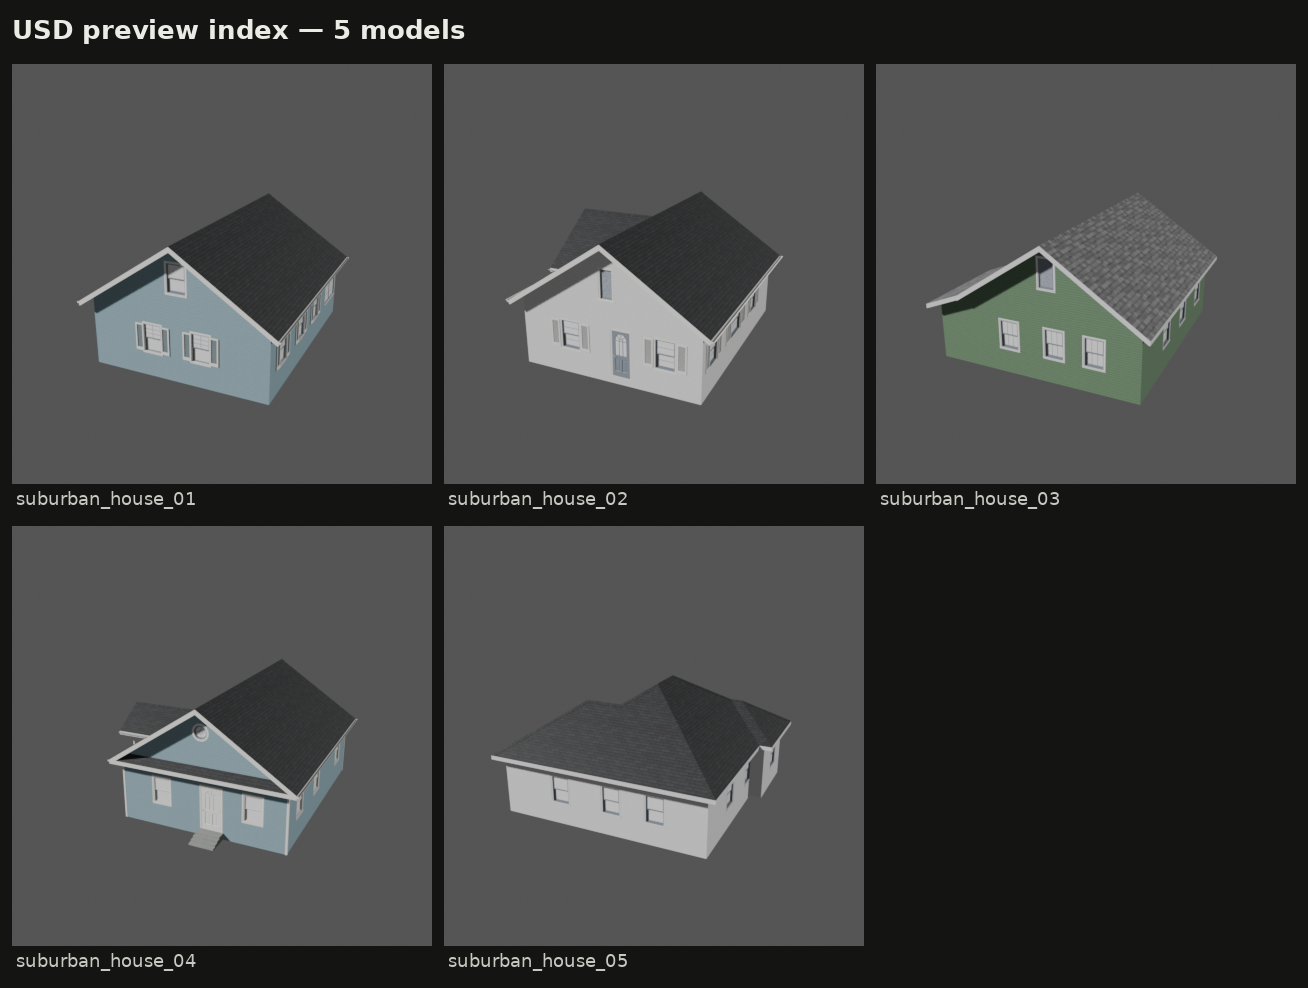

In [2]:
# Final check: render the **USD**, not the source glb. A conversion that lost
# its textures still loads in Isaac Sim — it just shows up as untextured grey —
# so this is the only step that proves the materials survived Blender.
import subprocess
from IPython.display import Image as IPyImage, display

PREVIEWS = os.path.join(oa.ASSET_DIR, ".previews")
proc = subprocess.run(
    ["uv", "run", "--script", os.path.join(SCENE_GEN, "render_usd.py"),
     oa.ASSET_DIR, "--views", "2", "--res", "420", "--samples", "32",
     "-o", PREVIEWS],
    capture_output=True, text=True, cwd=SCENE_GEN)
print(proc.stdout.strip().splitlines()[-1] if proc.returncode == 0 else proc.stderr[-2000:])

display(IPyImage(filename=os.path.join(PREVIEWS, "index.png")))

## Findings

**The dataset.** Objaverse 1.0 is ~799k Sketchfab objects, and its annotations
carry texture count/resolution, face count, tags and license *without*
downloading anything — which is what makes filtering viable. About **50%**
survive the baseline filter (textured, unanimated, ≤400k faces). Objaverse-XL
is 10× bigger but its only searchable text is the file path and most of it is
untextured low-poly, so 1.0 is the right source here.

**Metadata gets you a shortlist, not a verdict.** Every disqualifier we hit was
about *shape*, invisible in the metadata:

* **dioramas** — a house modelled on a terrain/lawn disc. The generator lays
  its own ground and snaps assets to it, so a built-in base z-fights or leaves
  the house on a floating slab. The single most common failure.
* **photogrammetry scans** wrapped in a sky sphere or panorama dome.
* **stylised / fantasy / post-apocalyptic** art, and shacks. The generator
  applies its own damage, so it wants intact buildings.
* **`textureCount > 0` does not mean textured.** It counts images in the
  archive, not whether the materials sample them — `texture_report()` checks
  what actually loads.

So the loop is: filter hard on metadata, then *look at them*.

**Two traps worth remembering.**

1. `pyrender.Scene.from_trimesh_scene` raises on any non-mesh geometry, and a
   fair number of Objaverse glbs carry `Path3D` curves beside their meshes.
   Left unfixed it silently rejects good assets as "broken" — 3 of the first 15.
2. **Do not predict the converted asset's size from the source mesh.** Which
   source axis ends up "up" in the USD depends on the root transform inside the
   glTF, so a fixed Y-up→Z-up swap is right for some assets and wrong for
   others — it produced 10.6 m-tall bungalows. `convert_to_usd.py --report`
   returns the bbox from Blender's world coordinates, which *are* the USD's.

**The result.** The `Bungalow The <name>` family (22 assets, all CC-BY, 1024px
textures, 25–120k faces) is a strong vein for the suburban set: detached
single-family houses, one consistent art direction, varied rooflines, no ground
plates. Five are wired into `config/asset_sets/suburban.yaml` at a 12 m plan
dimension (~6.4 m tall).

**Assets are addressed by Objaverse uid**, not by any local name — the cache
lives at `assets/objaverse/<uid>/<uid>.usdc`, so it is a pure function of what
the config asked for and the config stays meaningful with an empty cache.
`airstack up` runs `objaverse_assets.py sync`, which downloads and converts
anything missing before the sim starts; `ensure` is idempotent, so a warm cache
costs nothing (the import cell above prints nothing on a re-run).

The metric scale is **baked into the cached USD**, which is why the asset-set
entries carry `target-size-m` and no `scale:` — the generator measures a
metric asset and there is no factor to drift from the geometry.

**Verified end to end.** With the cache deleted, `SCENE_CONFIG=suburban
airstack up isaac-sim` re-fetched and converted all five (~11 s), then the sim
measured them at `scale=1.0` and placed 245 houses with no reference failures
and 0 placeholder prisms.


In [12]:
# ---------------------------------------------------------------------------
# Tornado aftermath for the suburban set
# ---------------------------------------------------------------------------
# The suburban set currently inherits urban's ruins and debris: concrete
# mid-rise shells, brick and cinder block. Reference photography of a tornado
# through a US subdivision shows something different — light wood framing,
# roof sheathing, snapped trees, and scraped earth. Three pools to replace:
#
#   buildings.damaged/destroyed  wrecked *houses*, not concrete shells
#   debris.pieces                lumber, planks, roof panels, branches
#   debris.piles                 dirt/soil mounds and mixed rubble heaps
#
# Ruined art is exactly what the earlier suburban query *excluded*, so these
# queries invert that filter.
RUINED_HOUSE = (r"destroyed house|ruined house|damaged house|abandoned house|"
                r"wrecked house|burnt house|derelict house|broken house|"
                r"house ruins|destroyed home|damaged building|destroyed building|"
                r"ruined building|collapsed")
NOT_RUINED = (r"interior|room|kitchen|bathroom|bedroom|furniture|"
              r"castle|church|temple|tower|medieval|fantasy|"
              r"skyscraper|apartment|factory|warehouse|bunker|"
              r"tank|vehicle|character|weapon|zombie|"
              r"city|street|village|town|diorama|scene|environment|terrain")

ruined = oa.search(catalog, RUINED_HOUSE, exclude=NOT_RUINED,
                   min_textures=1, min_texture_res=512,
                   min_faces=1_000, max_faces=300_000, sort="likes")
print(f"{len(ruined):,} ruined-house candidates")
print(ruined[["uid", "name", "faces", "texture_res", "license", "likes"]].head(12).to_string(index=False))

44 ruined-house candidates
                             uid                                        name  faces  texture_res license  likes
a0c01ce35a474545b805c0739806aace                             Abandoned House  12234         2048      by    444
6fa85b289def499c95afd232173ecc27 Abandoned Building: Polygraphenwerk Leipzig 295894         8192      by    254
1ec9ef29c1604487a2f498df7e744c88                         Passenger Car(Rail)  16033         2048      by    173
32928796ada54eddaf2e9ae9d3cdf026                             destroyed house   3132         2048      by    172
1aa481727ca54c59834a4f311b43e0cd                          Abandoned building   9122         4096      by    154
d2ab8669d0d346eda44fa35d793bdc81          Old Stone Tile (With Displacement)  36864         4096      by    123
8a95ab9548314c66bb0bf7c2191da80c                   Destroyed building, study  24114         2048   by-nc    100
177e494fdada4b64b02acf041ae8cfdd               Destroyed House With Textures 

starting download of 20 objects with 8 processes


Downloaded

1

/

20

...

20

/

20

objects

downloaded 20/20


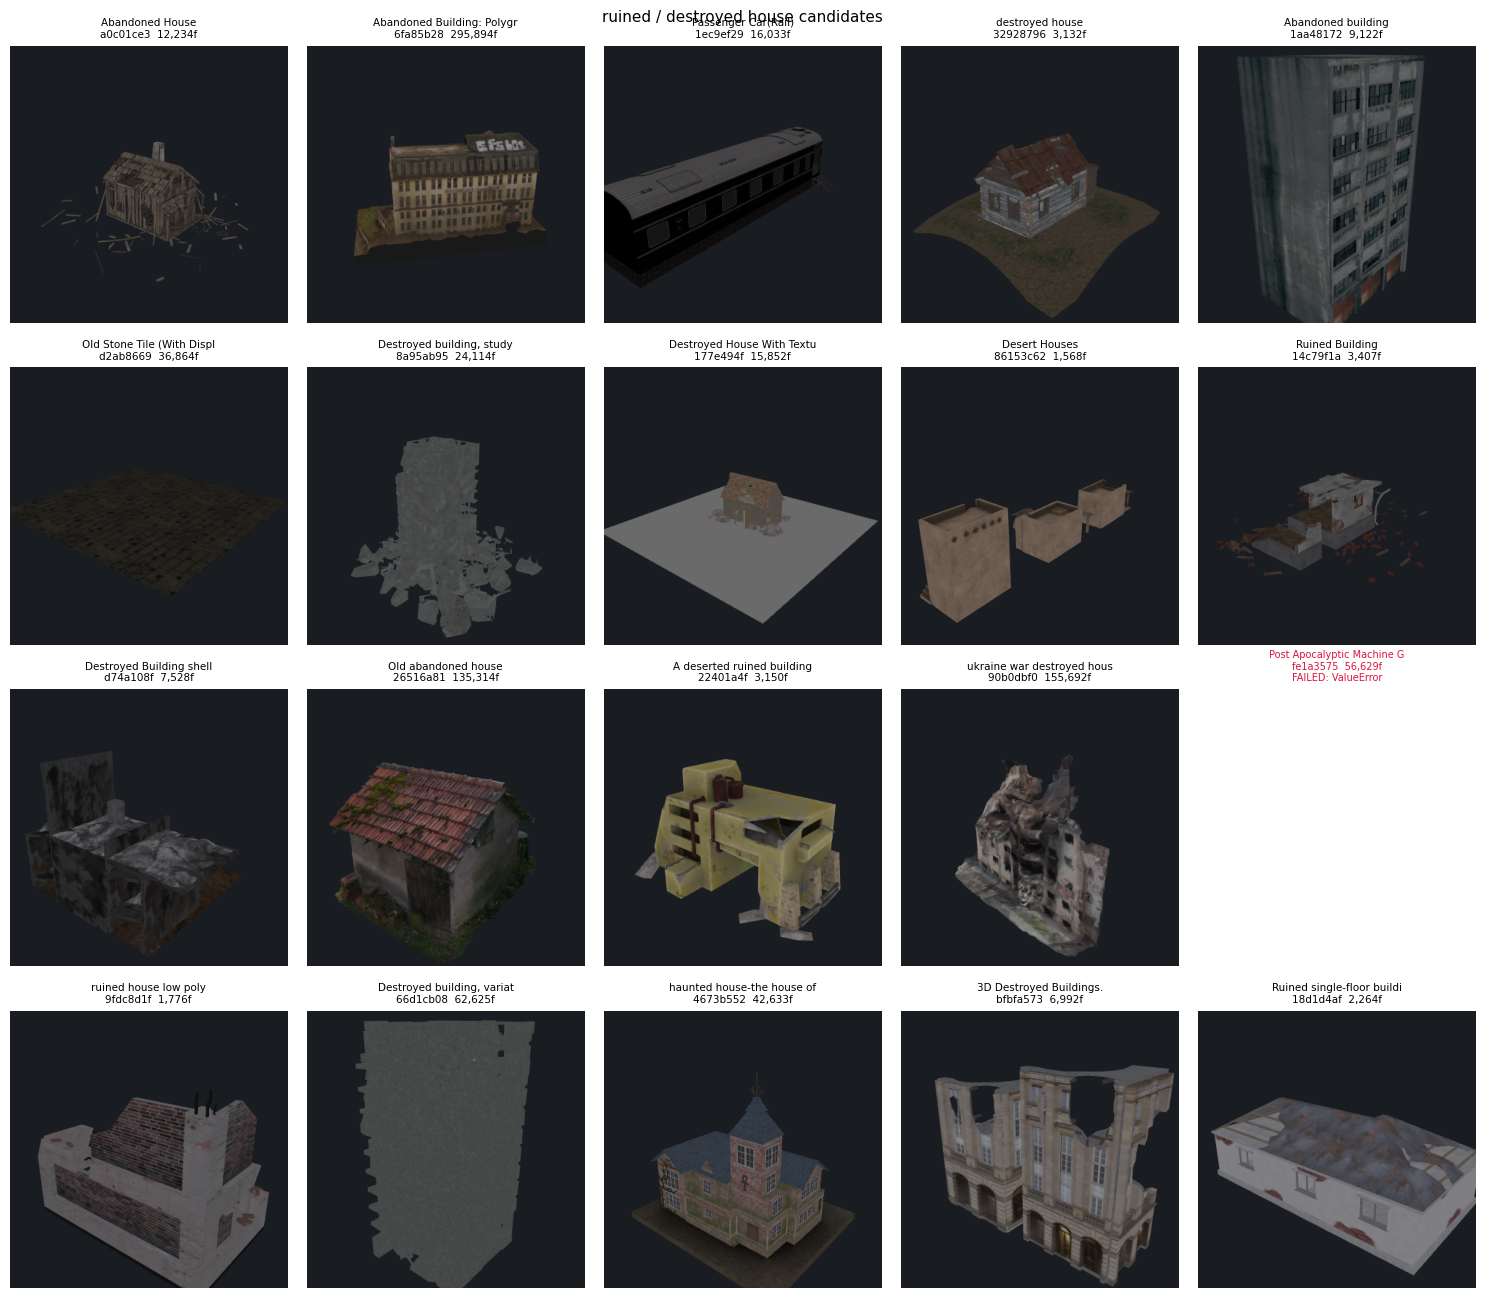

In [13]:
pool_ruin = preview(ruined, n=20, title="ruined / destroyed house candidates")

In [14]:
# That pass returned mostly European masonry ruins and apartment blocks — the
# wrong material story. Probe a range of phrasings cheaply (counts only) before
# spending downloads, across all three pools we need.
PROBES = {
    "storm/tornado damage": r"tornado|hurricane damage|storm damage|disaster house|"
                            r"wind damage|flattened|leveled house",
    "collapsed wood frame": r"collapsed house|collapsed building|rubble house|"
                            r"demolished|wreckage|debris house|destroyed home",
    "lumber / planks":      r"wood debris|wooden debris|planks|plank pile|lumber|"
                            r"timber|wood pile|broken wood|wood scrap|scrap wood|"
                            r"wooden beam|board pile",
    "roof / construction":  r"roof debris|shingle|roof panel|corrugated|"
                            r"construction debris|building debris|rubble pile",
    "fallen / broken tree": r"fallen tree|broken tree|dead tree|tree trunk|uprooted|"
                            r"tree stump|log|logs|branch|branches|fallen log|"
                            r"snapped tree|tree debris",
    "dirt / soil":          r"dirt pile|soil|dirt mound|mud|earth pile|gravel pile|"
                            r"dirt|ground debris|rubble heap|sand pile",
}

for label, pat in PROBES.items():
    hits = oa.search(catalog, pat, min_textures=1, min_texture_res=512,
                     max_faces=200_000)
    top = ", ".join(hits.sort_values("likes", ascending=False)
                    .head(4)["name"].str[:22])
    print(f"{label:22s} {len(hits):>5,}   {top}")

storm/tornado damage      19   Tornado Tree Trunk, Farm Disaster, Tornado, "Tornado" bottle can


collapsed wood frame      14   DC3 Plane Wreckage On , Set of 4 Concrete rubb, Low poly stone rubble , American Motor Over Sm


lumber / planks          754   Wood Kit, Wooden Forest Houses, Swamp Scene, Wooden Fences  [Low Po


roof / construction       31   Low | Farm | Assembly , Damaged Corrugated She, Heap of construction d, Rusted corrugated pane


fallen / broken tree     781   Lowpoly Sticks, Wood stick 01, Calvin and Hobbes Log , Wood Stick 04


dirt / soil              451   Wooden Table, Low | House | Building, Dusty Old Bookshelf (F, Metal Cabinet (Low Pol


50 storm-damage + construction-debris candidates


starting download of 20 objects with 8 processes


Downloaded

1

/

...

20

/

20

objects

downloaded 20/20


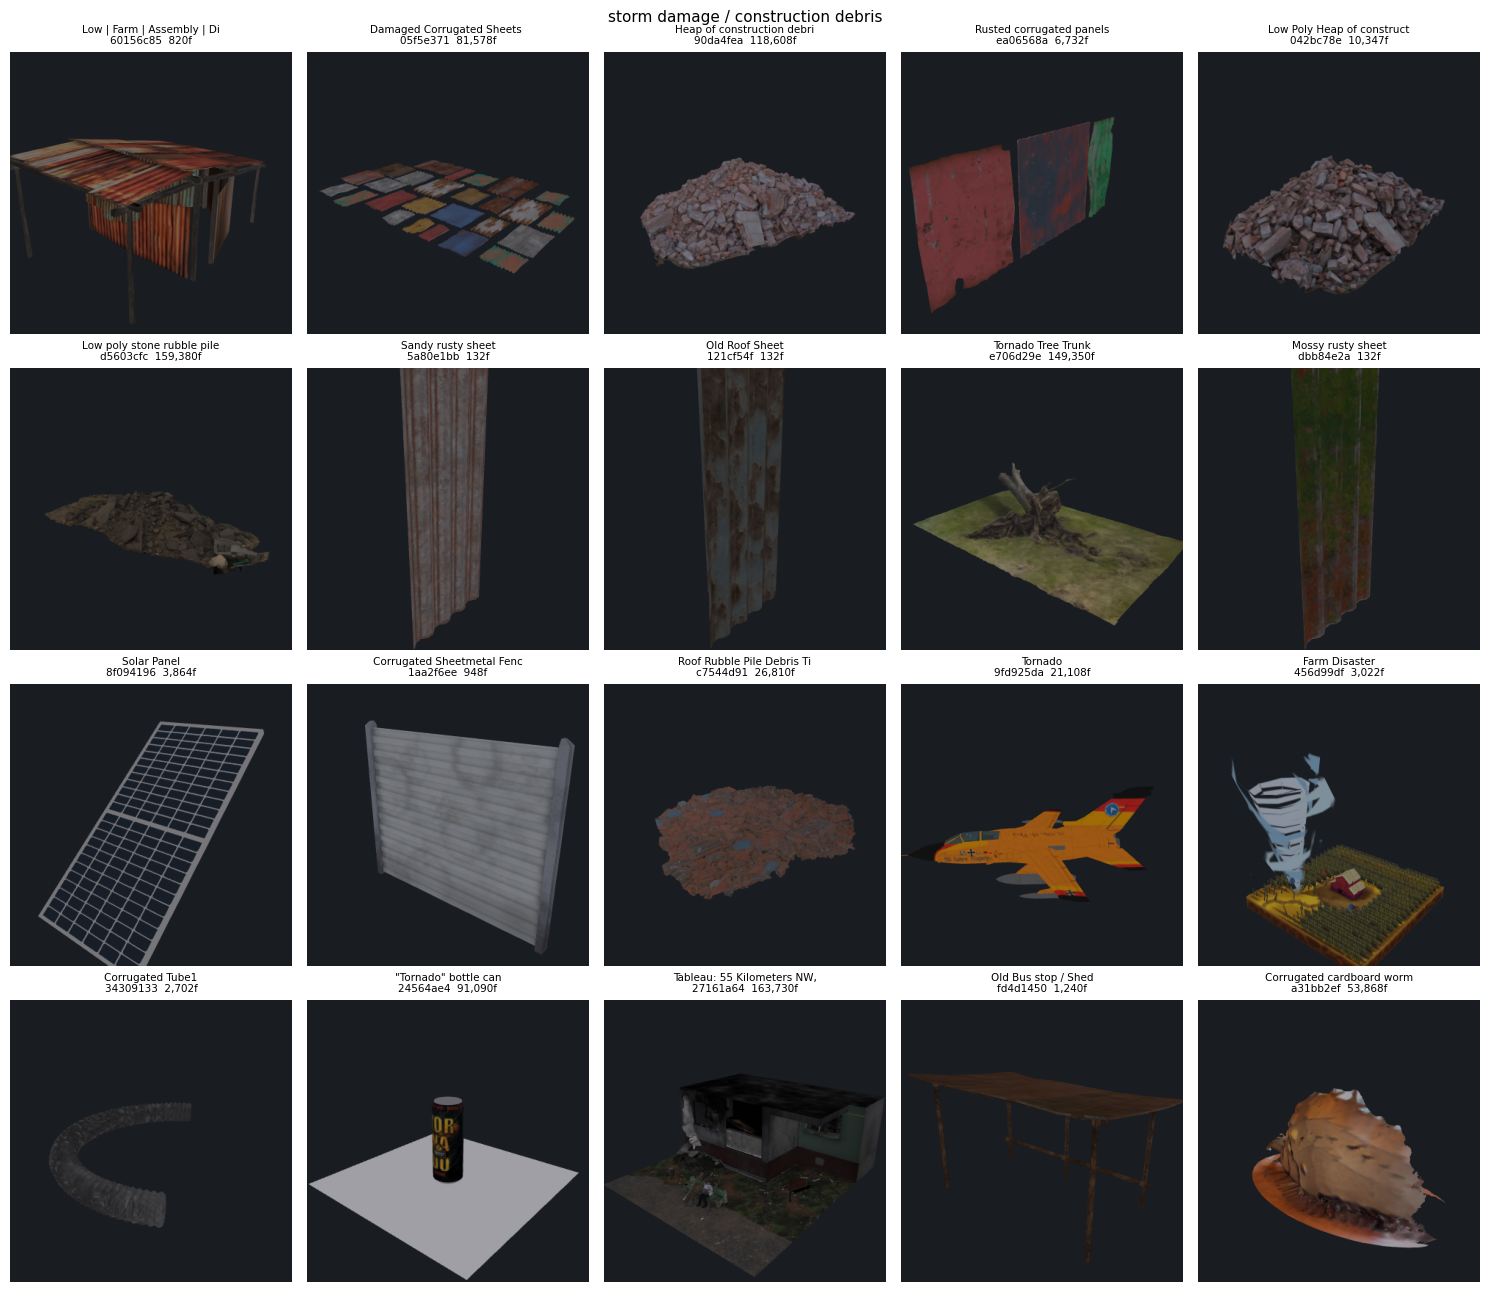

In [15]:
storm = oa.search(catalog, PROBES["storm/tornado damage"] + "|" + PROBES["roof / construction"],
                  min_textures=1, min_texture_res=512, max_faces=200_000, sort="likes")
print(f"{len(storm)} storm-damage + construction-debris candidates")
pool_storm = preview(storm, n=20, title="storm damage / construction debris")

1,086 wood-debris / downed-tree candidates


starting download of 20 objects with 8 processes


Downloaded

1

/

...

20

/

20

objects

downloaded 20/20


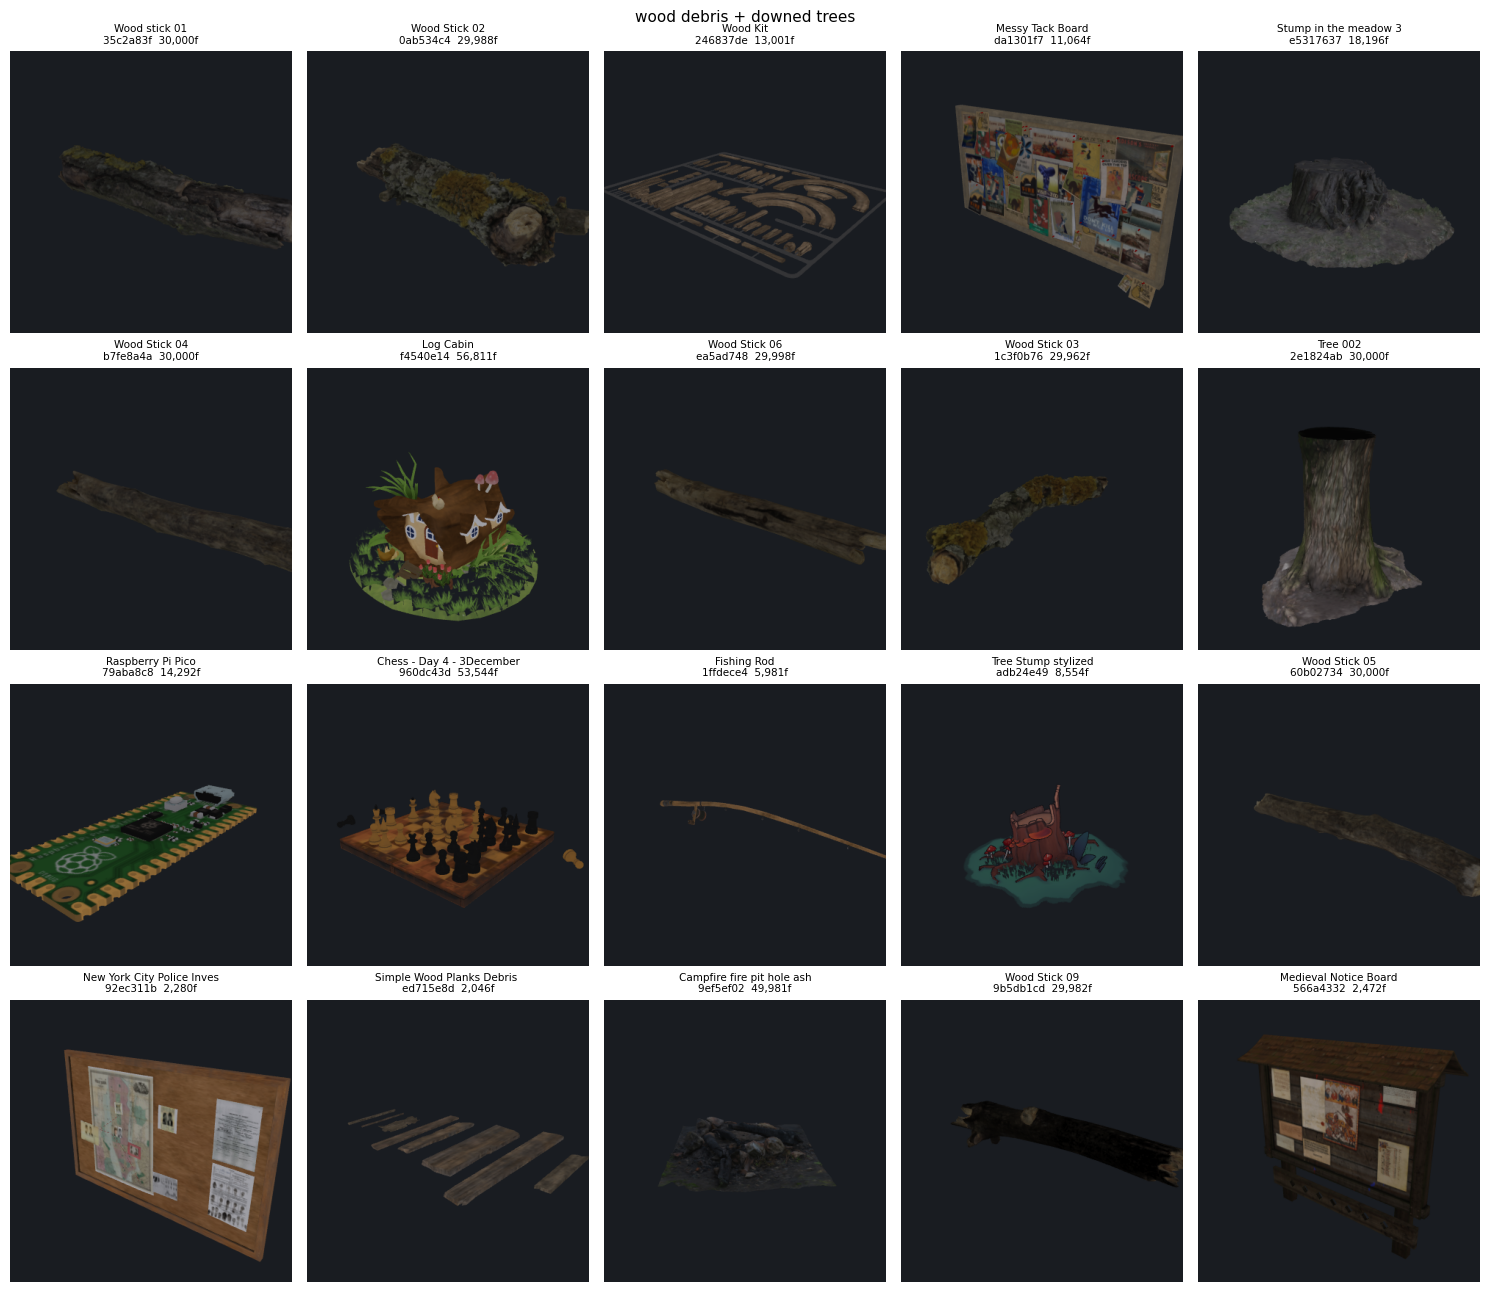

In [16]:
# Wood debris + downed trees. The broad probes matched furniture and whole
# forests, so exclude built/props uses of the same words: a "wooden table" and
# a "wood plank" share every keyword but only one is debris.
WOOD = (r"wood debris|wooden debris|plank|planks|lumber|timber|wood pile|"
        r"broken wood|scrap wood|wood scrap|wooden beam|board|"
        r"fallen tree|broken tree|dead tree|tree trunk|uprooted|log|logs|"
        r"branch|branches|stick|sticks|stump")
NOT_WOOD = (r"table|chair|desk|shelf|cabinet|bed|door|window|floor|fence|"
            r"house|building|room|interior|kitchen|furniture|barrel|crate|box|"
            r"boat|ship|guitar|weapon|sword|axe|character|"
            r"forest|scene|environment|diorama|terrain|island|"
            r"cutting|chopping|sign|pallet|bridge|stairs|roof")

wood = oa.search(catalog, WOOD, exclude=NOT_WOOD,
                 min_textures=1, min_texture_res=512,
                 min_faces=200, max_faces=120_000, sort="likes")
print(f"{len(wood):,} wood-debris / downed-tree candidates")
pool_wood = preview(wood, n=20, title="wood debris + downed trees")

In [17]:
# The "Wood Stick NN" family is the equivalent find to the bungalows: scanned
# branches/limbs, one art style, consistent scale. Exactly the fallen-limb
# debris the reference photo is full of.
sticks = oa.search(catalog, r"wood stick", min_textures=1, sort="likes")
print(f"{len(sticks)} in the Wood Stick family "
      f"(faces {int(sticks.faces.min()):,}–{int(sticks.faces.max()):,})")
print(sticks[["uid", "name", "faces", "texture_res", "license"]].head(12).to_string(index=False))

# Dirt / soil / scraped earth. The earlier probe matched furniture through tags,
# so anchor on pile-shaped nouns and reject the obvious prop senses.
DIRT = (r"dirt pile|dirt mound|soil pile|mud pile|earth mound|gravel pile|"
        r"sand pile|rubble pile|debris pile|pile of dirt|pile of rubble|"
        r"heap of|mound of|dirt heap|ground debris|rubble heap")
NOT_DIRT = (r"table|chair|shelf|book|cabinet|bowl|pot|plant|food|coin|"
            r"character|weapon|building|house|room|interior|vehicle")
dirt = oa.search(catalog, DIRT, exclude=NOT_DIRT, min_textures=1,
                 min_texture_res=512, max_faces=200_000, sort="likes")
print(f"\n{len(dirt)} dirt / rubble-pile candidates")
print(dirt[["uid", "name", "faces", "texture_res", "license"]].head(12).to_string(index=False))

15 in the Wood Stick family (faces 156–233,209)
                             uid                 name  faces  texture_res license
35c2a83f89da49b58d41dea9ca5ed330        Wood stick 01  30000         4096      by
0ab534c493e14f67bac01ee94f20e43f        Wood Stick 02  29988         4096      by
b7fe8a4a3c2f4f038662ae47cfbfa6a7        Wood Stick 04  30000         4096      by
ea5ad74839744adeb7126b6d324cfb45        Wood Stick 06  29998         4096      by
1c3f0b7635e342f2bf3789a6bae48b1d        Wood Stick 03  29962         4096      by
60b02734e3c545bd9a66e5d42e6eee54        Wood Stick 05  30000         4096      by
f3214bfd52fb4868a094e45d9a189af8        Wood Stick 08 100000         4096      by
9b5db1cddf1e4fc399f47c80b31462c2        Wood Stick 09  29982         4096      by
0b82cbdb8d4841b7904508af2328fb1e        Wood Stick 10 100000         4096      by
9fc71dcbaec644878e284a9d9c25ea03        Wood Stick 07  93035         4096      by
aedb8f44f78944c7a1d53ff14c6d3290 Wood Stick 08 Rem


30 dirt / rubble-pile candidates
                             uid                                            name  faces  texture_res license
107f6a1f6aa74449bcd32ef136311d86                                  A pile of sand  19373         4096      by
945d60fd01874c029a1e0cdef1184995                                     Stone Floor   1285         4096      by
042bc78e7d1d4275b3cd87e97f35d11c     Low Poly Heap of construction debris bricks  10347         2048      by
d5603cfcc8d0427a912520077dbda3b4                      Low poly stone rubble pile 159380         8192      by
0ab5415789a1454a925d82f0650910ff Heap of construction old debris bricks - remake   5146         2048      by
40e5a44c537140f083f1958cf9f3d18b                                 Small Dirt Pile     96         2048      by
2176ea4691054f229f2b2539ae126afe                               Simple Brick Pile   3960         4096      by
b3b11017332040d6b717839c07a782c4                                 Large Dirt Pile    200       

starting download of 8 objects with 8 processes


Downloaded

1

/

8

...

8

/

8

objects

downloaded 11/11


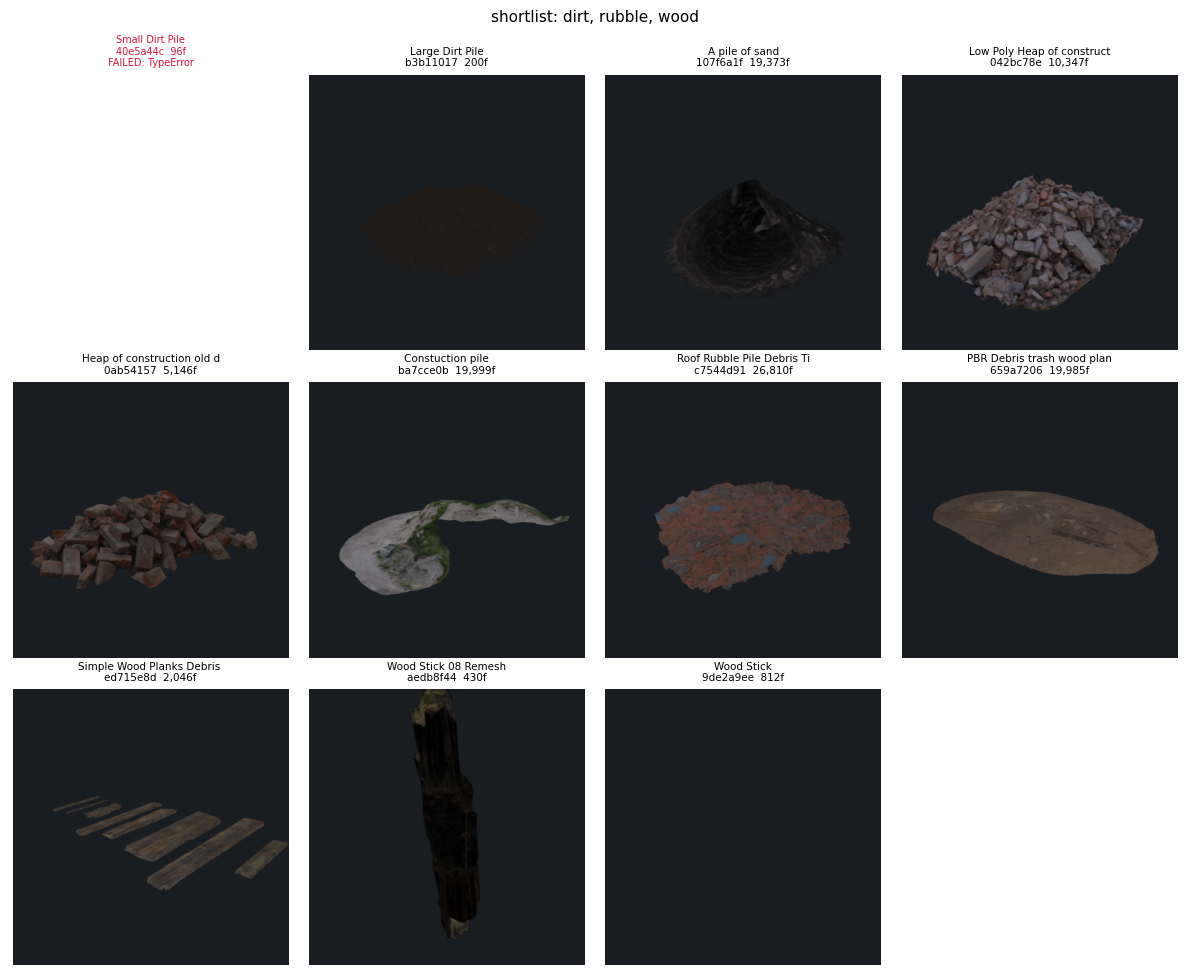

In [20]:
# Shortlist across all three pools. Poly budget matters here in a way it didn't
# for houses: a tornado scene scatters ~1000 debris pieces, so a 30k-face
# scanned branch costs 30M faces where a 430-face remesh costs 0.4M. Prefer the
# cheap variants for `pieces`, and keep the detailed ones for `piles` (dozens,
# not hundreds).
SHORTLIST = [
    # dirt / earth
    "40e5a44c537140f083f1958cf9f3d18b",  # Small Dirt Pile          96f
    "b3b11017332040d6b717839c07a782c4",  # Large Dirt Pile         200f
    "107f6a1f6aa74449bcd32ef136311d86",  # A pile of sand        19,373f
    # mixed construction rubble
    "042bc78e7d1d4275b3cd87e97f35d11c",  # Low Poly Heap of debris 10,347f
    "0ab5415789a1454a925d82f0650910ff",  # Heap of old debris       5,146f
    "ba7cce0be4a045558ff670e9348cfd78",  # Constuction pile        19,999f
    "c7544d9183c24ed3a716f8255536afa8",  # Roof Rubble Pile        26,810f
    # wood
    "659a7206daec4a968c35a71bbb4768aa",  # Debris trash wood planks 19,985f
    "ed715e8d9c8745a091f094e3abdb1ff7",  # Simple Wood Planks Debris Pack 2,046f
    "aedb8f44f78944c7a1d53ff14c6d3290",  # Wood Stick 08 Remesh      430f
    "9de2a9ee111d487f9c7e7d78c625cdd8",  # Wood Stick                812f
]

rows = catalog[catalog.uid.isin(SHORTLIST)].set_index("uid").loc[SHORTLIST].reset_index()
pool_short = preview(rows, n=len(rows), cols=4, res=400, title="shortlist: dirt, rubble, wood")

In [19]:
print(catalog[catalog["name"].str.contains("Wood Planks", case=False, na=False)]
      [["uid", "name", "faces", "texture_res"]].head(8).to_string(index=False))

                             uid                                name   faces  texture_res
d65943c5a6f943c88e6cc92b901cd380                      Wood Planks 01 1015808         4096
8991aa69e65e42cb81be7011ee980971 Wood planks modeles in Hard Surface    8364            0
ed715e8d9c8745a091f094e3abdb1ff7      Simple Wood Planks Debris Pack    2046         2048
bff2939374854e2fb899afd0fc90ffb0                Low Poly Wood Planks    4924         1024
d5502623455446c3983d2eed057151cd              Old Bloody Wood Planks     736         2048
f6251b5a2a254518924e9849f1e15c29                         Wood Planks   76800         4096
27968674d5f848af97b84fd632460562           Floor wood planks texture   80000         4096
1901d8f1e7354ea289860d29c6ba0046             Set of wood Wood Planks    7104         4096


Abandoned House (wood-frame collapse)      textures {'textured_meshes': 644, 'untextured_meshes': 0}
Wood Stick (rendered black)                textures {'textured_meshes': 1, 'untextured_meshes': 0}
A pile of sand (rendered black)            textures {'textured_meshes': 1, 'untextured_meshes': 0}
Small Dirt Pile (render failed)            textures {'textured_meshes': 1, 'untextured_meshes': 0}


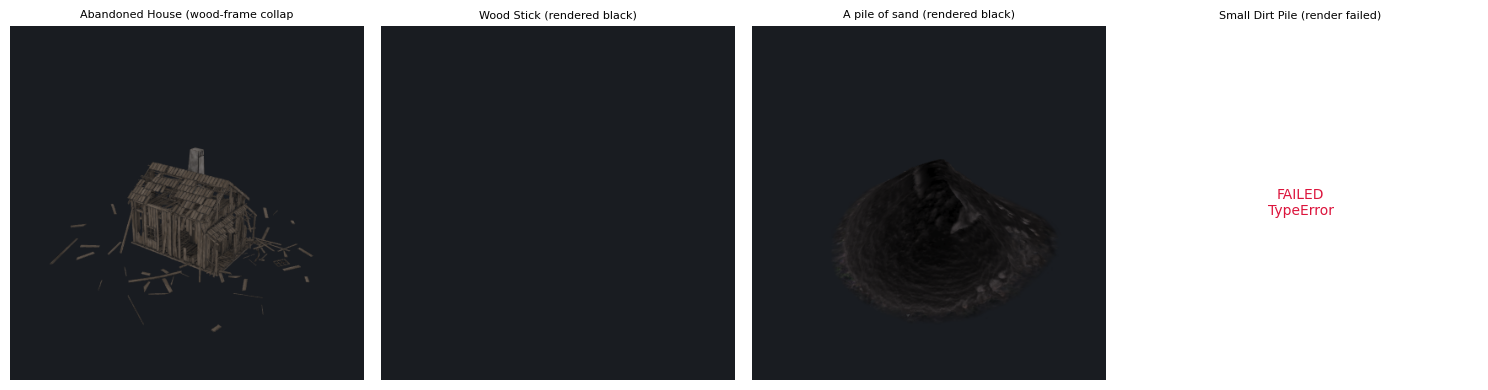

In [21]:
# Three things to settle before committing:
#  1. a0c01ce3 is the only genuine wood-frame collapse the ruin query found —
#     check it from two angles.
#  2. several shortlist items rendered near-black; separate "dark albedo" from
#     "untextured / broken".
#  3. 40e5a44c failed to render at all.
CHECK = {
    "a0c01ce35a474545b805c0739806aace": "Abandoned House (wood-frame collapse)",
    "9de2a9ee111d487f9c7e7d78c625cdd8": "Wood Stick (rendered black)",
    "107f6a1f6aa74449bcd32ef136311d86": "A pile of sand (rendered black)",
    "40e5a44c537140f083f1958cf9f3d18b": "Small Dirt Pile (render failed)",
}
paths_chk = oa.download(list(CHECK), processes=4)
for uid, label in CHECK.items():
    try:
        print(f"{label:42s} textures {texture_report(paths_chk[uid])}")
    except Exception as exc:
        print(f"{label:42s} LOAD FAILED: {type(exc).__name__}: {exc}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (uid, label) in zip(axes, CHECK.items()):
    try:
        ax.imshow(render_glb(paths_chk[uid], res=420, azim=35, elev=25))
    except Exception as exc:
        ax.text(0.5, 0.5, f"FAILED\n{type(exc).__name__}", ha="center", va="center",
                color="crimson", transform=ax.transAxes)
    ax.set_title(label[:34], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

USD import of '/tmp/aftermath__vr08t8g/ed715e8d9c8745a091f094e3abdb1ff7/ed715e8d9c8745a091f094e3abdb1ff7.usdc' took 6.36 ms


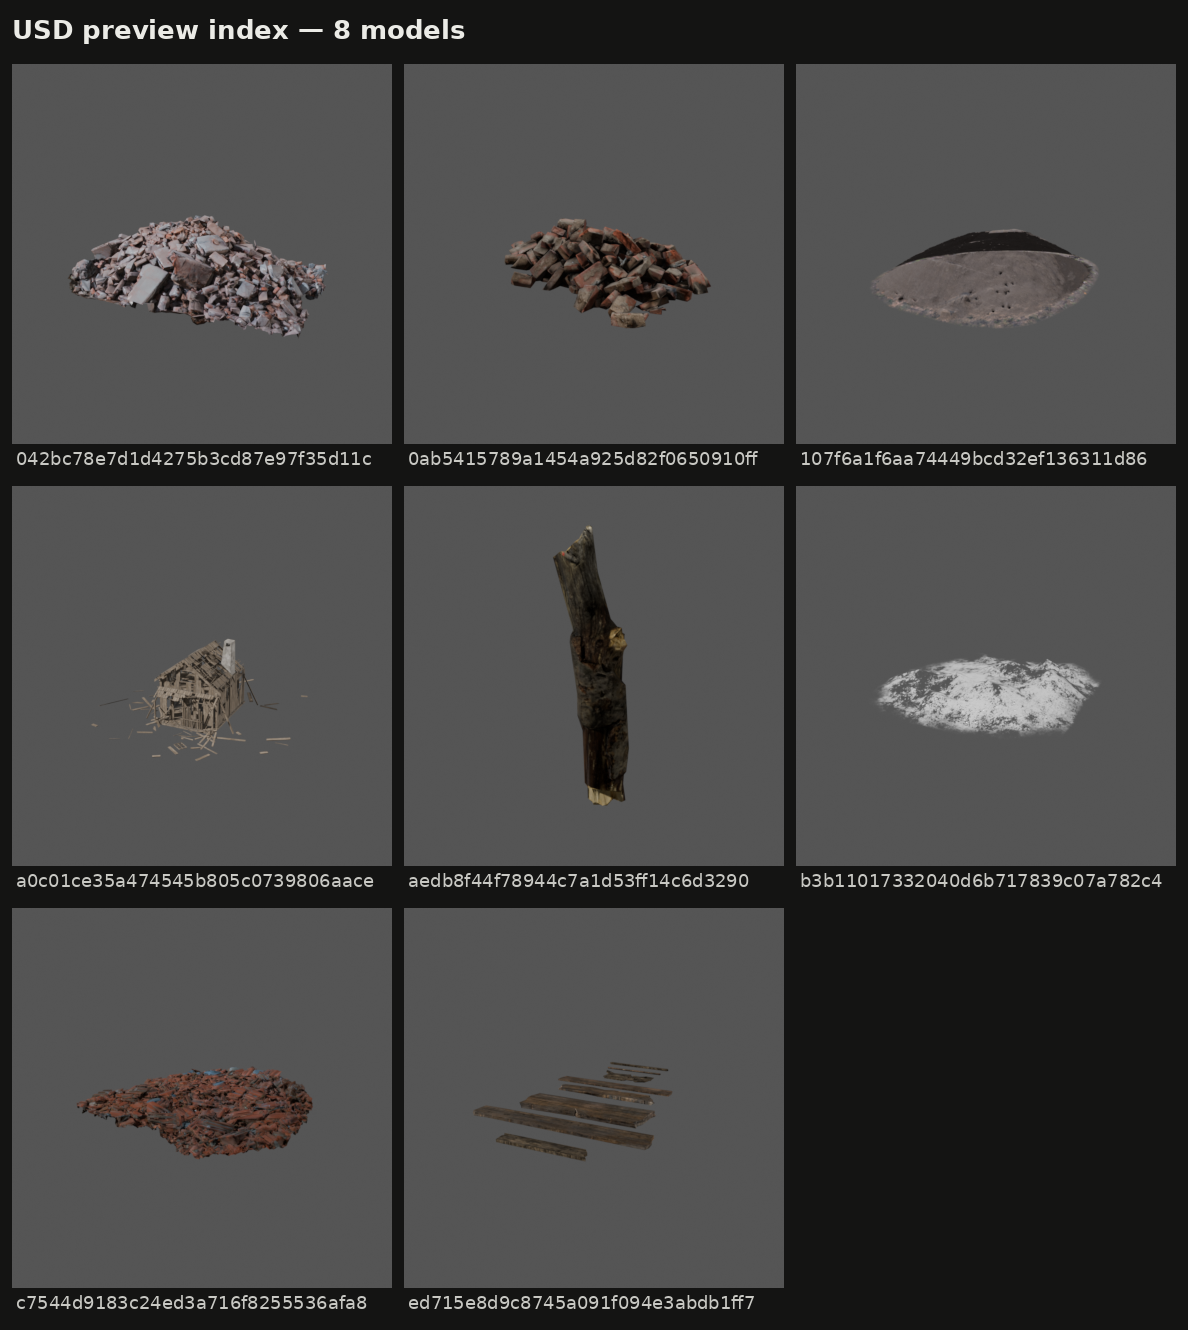

In [22]:
# Render the *converted USDs* for the new aftermath assets — the only check
# that textures survived Blender. (Scoped to the 8 new uids so this doesn't
# re-render the houses every time.)
import shutil, subprocess, tempfile
from IPython.display import Image as IPyImage, display

NEW = ["a0c01ce35a474545b805c0739806aace", "aedb8f44f78944c7a1d53ff14c6d3290",
       "ed715e8d9c8745a091f094e3abdb1ff7", "b3b11017332040d6b717839c07a782c4",
       "107f6a1f6aa74449bcd32ef136311d86", "042bc78e7d1d4275b3cd87e97f35d11c",
       "0ab5415789a1454a925d82f0650910ff", "c7544d9183c24ed3a716f8255536afa8"]

stage_dir = tempfile.mkdtemp(prefix="aftermath_")
for uid in NEW:
    shutil.copytree(os.path.join(oa.ASSET_DIR, uid), os.path.join(stage_dir, uid))

out = os.path.join(oa.ASSET_DIR, ".previews_aftermath")
proc = subprocess.run(
    ["uv", "run", "--script", os.path.join(SCENE_GEN, "render_usd.py"),
     stage_dir, "--views", "1", "--res", "380", "--samples", "32", "-o", out],
    capture_output=True, text=True, cwd=SCENE_GEN)
print(proc.stdout.strip().splitlines()[-1] if proc.returncode == 0 else proc.stderr[-1500:])
shutil.rmtree(stage_dir, ignore_errors=True)
display(IPyImage(filename=os.path.join(out, "index.png")))

## Second pass — tornado aftermath for the suburban set

Driven by reference photography of a tornado through a US subdivision: the
damage is **light wood framing, roof sheathing, snapped limbs and scraped
earth**, whereas the suburban set had inherited urban's concrete-and-cinder-block
rubble. Three pools needed replacing.

**What Objaverse actually has, by pool:**

| Pool | Result |
|---|---|
| wrecked *houses* | **Thin.** 44 candidates; essentially one usable — `a0c01ce3` "Abandoned House", a genuine timber-frame collapse on its slab with planks thrown clear. Nearly everything else is European masonry, concrete apartment blocks, or sits on a modelled ground plate. |
| wood debris | **Good.** `ed715e8d` "Simple Wood Planks Debris Pack" (2k faces) and the `Wood Stick NN` scanned-branch family, of which `aedb8f44` "Wood Stick 08 Remesh" is the only low-poly member (430 faces). |
| dirt / rubble piles | **Good.** Dirt and sand mounds at 200–19k faces, plus brick/construction heaps and a flat roof-tile scatter. |

Also **removed** the 16 `Brick_red_*` / `Brick_white_*` / `Blok_*` Nucleus
pieces from this set — wood-frame houses don't leave cinder block behind. The
generic `Debris_*` chunks stay, for variety.

**Two things this pass taught the pipeline:**

1. **Poly budget is a selection criterion for debris, unlike for buildings.** A
   scene scatters ~700 debris pieces against ~110 houses, so a 30k-face scanned
   branch costs 20M faces where its 430-face remesh costs 0.3M. Detailed scans
   are fine for `piles` (dozens of instances), not for `pieces`.
2. **`fit: footprint` is wrong for long thin objects.** The branch was scanned
   standing on end, so pinning its *plan* stretched it into a 7.4 m spike.
   `fit: max` pins the length instead — hence the new `fit` key on asset-set
   entries. (Debris is dropped and physics-settled, so it lands flat regardless
   — but at the right size only with `max`.)

**Caveat worth checking in-sim:** `b3b11017` "Large Dirt Pile" renders white in
the USD preview above, though its albedo texture is verifiably brown
(mean RGB 92,79,66) and correctly bound. That looks like this preview renderer
mis-wiring a 3-map material rather than a broken asset — but if it shows up
white in Isaac Sim, it's the one to drop.


In [23]:
# Licence audit: everything else in the set is CC-BY, but the planks pack is
# by-nc. Worth knowing, and worth checking whether a BY-licensed plank asset
# exists before accepting the extra obligation.
planks = oa.search(catalog, r"wood plank|planks|lumber|board pile|timber",
                   exclude=r"table|chair|floor|fence|wall|house|texture|"
                           r"furniture|door|guitar|pallet|bridge",
                   min_textures=1, licenses="by,cc0",
                   min_faces=300, max_faces=30_000, sort="likes")
print(f"{len(planks)} BY/CC0 plank-ish candidates")
print(planks[["uid", "name", "faces", "texture_res", "license", "likes"]]
      .head(10).to_string(index=False))

608 BY/CC0 plank-ish candidates
                             uid                                 name  faces  texture_res license  likes
d331f79189704cd49ba013752f2b8d80                           Wood Crate   1242         4096      by    102
7457a6729081456fb0b9cabf57fc1734 Kenworth W-900 A 1973 Timber Carrier  18744         1024      by     72
1901d8f1e7354ea289860d29c6ba0046              Set of wood Wood Planks   7104         4096      by     69
025e9f1cb3bd4256ba7570aa991be29b      Pile of Planks (Free/GameReady)   3038         1024      by     60
1b31413d89a4485e93f4bdb9eb735d88                    Planches - Planks    512         2048      by     56
5599b67d36254221b247811b561c998e         Common Wood Plank Dimensions   2280         4096      by     52
2341e9c2456f4876b2e86a9465724b0d                       Planks Of Wood    534         2048      by     48
45a000ef6fda466d997a487b5a9640a1                                Crate   5908         4096      by     41
bff2939374854e2fb899afd

starting download of 3 objects with 4 processes


Downloaded

1

/

3

...

Downloaded

3

/

3

objects

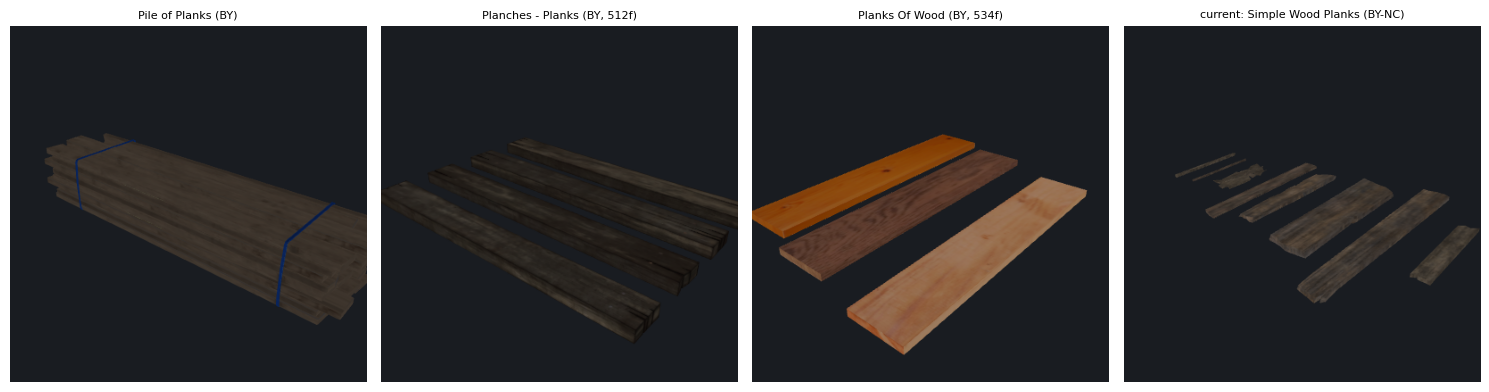

In [24]:
CAND = {"025e9f1cb3bd4256ba7570aa991be29b": "Pile of Planks (BY)",
        "1b31413d89a4485e93f4bdb9eb735d88": "Planches - Planks (BY, 512f)",
        "2341e9c2456f4876b2e86a9465724b0d": "Planks Of Wood (BY, 534f)",
        "ed715e8d9c8745a091f094e3abdb1ff7": "current: Simple Wood Planks (BY-NC)"}
pc = oa.download(list(CAND), processes=4)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (uid, label) in zip(axes, CAND.items()):
    try:
        ax.imshow(render_glb(pc[uid], res=400, azim=40, elev=28))
    except Exception as exc:
        ax.text(.5, .5, f"FAILED\n{type(exc).__name__}", ha="center", va="center",
                color="crimson", transform=ax.transAxes)
    ax.set_title(label, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

17 unused family members; taking the cheap ones

                             uid                  name  faces  texture_res  license
85961c7ab0d14a9a8766fe58f28886a8   Bungalow The Dawson  25203         1024       by
19331875f8d84137a94003f0660e2a50   Bungalow The Haynes  27627         1024       by
1ca9bf31b9d34b44a9b9cac8c240a8d7   Bungalow The Crosby  28626         1024       by
bee0da9227fa40029ad5352a2075ead8     Bungalow The Hale  29377         1024       by
968ca5757023470ab603067d79f713fc  Bungalow The Goodson  29458         1024       by
71474e859887459a96d2d281ffe53f18  Bungalow The Colbert  29458         1024       by
ab67dc215f8344eabadeeae05eacd887     Bungalow The Cass  29489         1024       by
f87535ec6d9a475db58965aa46ba6979  Bungalow The Clayton  29689         1024       by
3bc5f70542014501a1e380891295299e  Bungalow The Newport  29691         1024       by
7c64a6d90567428eb511f41036fe2d88   Bungalow The Walton  30165         1024       by
f5ccb6798dbf4f4fb3d1423113c

starting download of 7 objects with 8 processes


Downloaded

1

/

...

7

/

7

objects

downloaded 10/10


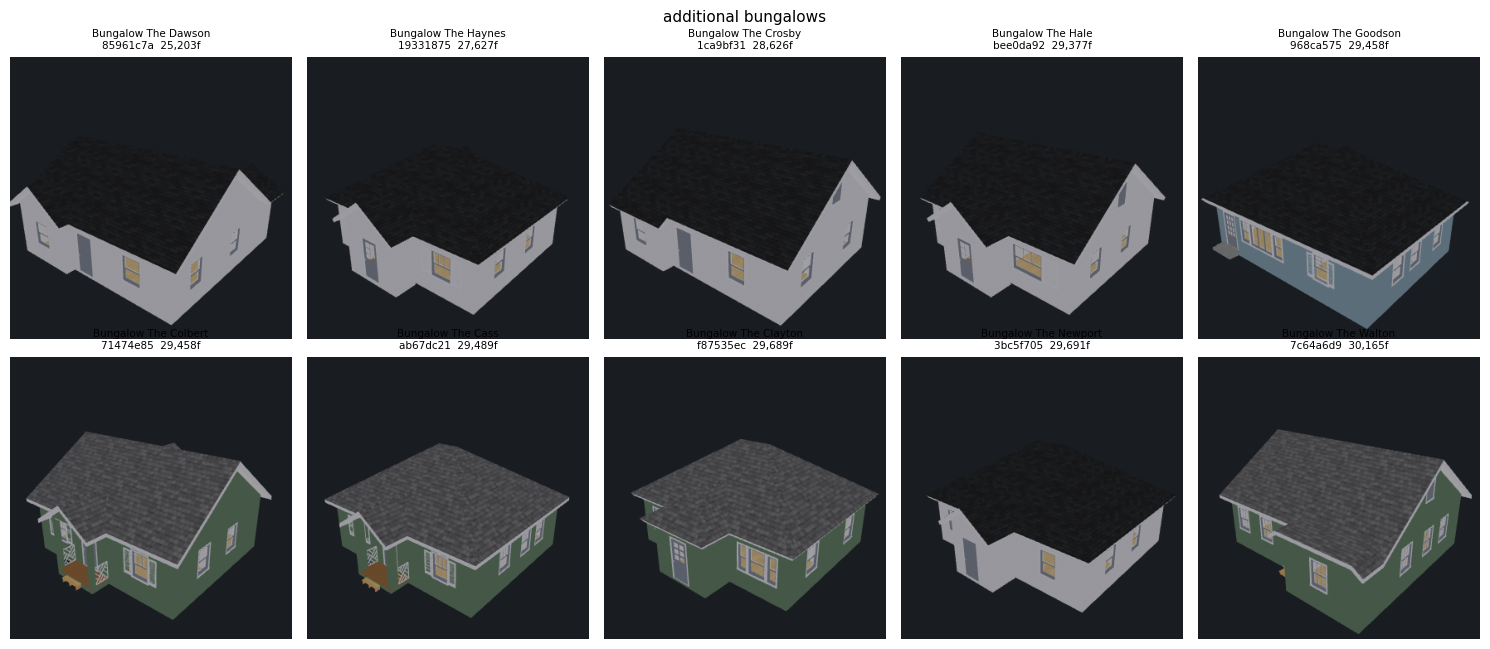

In [25]:
# More house variety: the bungalow family has 22 members and we were using 5.
# Take the rest of the low-poly ones — a neighborhood of 111 houses drawn from
# 5 prototypes reads as copy-paste from the air, which is exactly the altitude
# the drone flies at.
more = fam[~fam.uid.isin(SELECTION)].sort_values("faces")
print(f"{len(more)} unused family members; taking the cheap ones\n")
print(more[["uid", "name", "faces", "texture_res", "license"]].head(14).to_string(index=False))
EXTRA = more[more.faces <= 40_000].head(10)
print(f"\nadding {len(EXTRA)} (<=40k faces each)")
_ = preview(EXTRA, n=len(EXTRA), cols=5, res=340, title="additional bungalows")

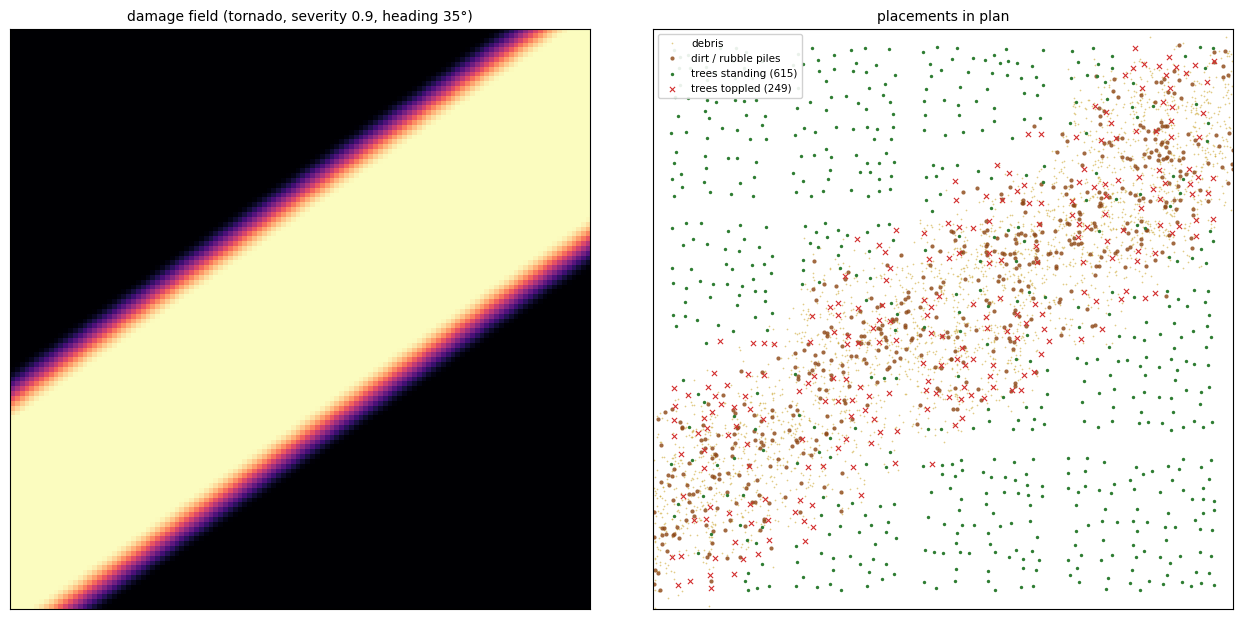

In [28]:
# Plan view of a tornado/suburban scene — does the scour actually read as a
# *line* across the region, or just as more debris around the same ruins?
#
# The build runs under /usr/bin/python3, which has `pxr`; this kernel has the
# plotting stack but not USD, so the two halves talk through a JSON dump.
import json, subprocess, textwrap

BUILD = textwrap.dedent('''
    import sys, yaml, json
    sys.path.insert(0, ".")
    from compile_disaster import compile_spec, DEFAULT_BASE
    import scene_generator as sg
    base = yaml.safe_load(open(DEFAULT_BASE))
    cfg = compile_spec({"locale": "suburban", "disaster-type": "tornado",
                        "severity": 0.9, "heading_deg": 35, "seed": 7}, base)
    cfg = sg.resolve_asset_set(cfg); cfg["measure_usds"] = False
    cfg.setdefault("fallback_sizes", {})["house"] = [12.0, 12.0]
    pl, layout = sg.build_city(cfg, sg._make_resolver(cfg))
    rx0, ry0, rx1, ry1 = layout["region"]
    f = sg.make_damage_field(cfg.get("disaster", {}).get("field"), layout["region"])
    n = 120
    json.dump({"region": layout["region"],
               "pts": [{"c": p["category"], "x": p["x_m"], "y": p["y_m"],
                        "roll": p.get("roll_deg", 0.0)} for p in pl
                       if p["category"] in ("debris", "debris_pile", "tree")],
               "field": [[f(rx0 + (rx1-rx0)*(i+.5)/n, ry0 + (ry1-ry0)*(j+.5)/n)
                          for i in range(n)] for j in range(n)]},
              open("/tmp/scour.json", "w"))
''')
subprocess.run(["/usr/bin/python3", "-c", BUILD], cwd=SCENE_GEN,
               capture_output=True, text=True, check=True)
d = json.load(open("/tmp/scour.json"))

rx0, ry0, rx1, ry1 = d["region"]
pts = d["pts"]
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
axes[0].imshow(d["field"], origin="lower", extent=[rx0, rx1, ry0, ry1],
               cmap="magma", vmin=0, vmax=1)
axes[0].set_title("damage field (tornado, severity 0.9, heading 35°)", fontsize=10)

ax = axes[1]
sel = lambda c: ([p["x"] for p in pts if p["c"] == c], [p["y"] for p in pts if p["c"] == c])
ax.scatter(*sel("debris"), s=1.5, c="#c9a227", label="debris", alpha=.55, lw=0)
ax.scatter(*sel("debris_pile"), s=9, c="#8b4513", label="dirt / rubble piles", alpha=.8, lw=0)
up = [p for p in pts if p["c"] == "tree" and abs(p["roll"]) <= 45]
dn = [p for p in pts if p["c"] == "tree" and abs(p["roll"]) > 45]
ax.scatter([p["x"] for p in up], [p["y"] for p in up], s=6, c="#2e7d32",
           label=f"trees standing ({len(up)})", lw=0)
ax.scatter([p["x"] for p in dn], [p["y"] for p in dn], s=14, c="#d32f2f", marker="x",
           label=f"trees toppled ({len(dn)})", lw=.8)
ax.set_xlim(rx0, rx1); ax.set_ylim(ry0, ry1); ax.set_aspect("equal")
ax.set_title("placements in plan", fontsize=10)
ax.legend(loc="upper left", fontsize=7.5, framealpha=.9)
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### What the plan view confirms

The band is the point. Building debris alone inherits the *layout* — it clusters
on lots and stops at property lines — so before this pass a tornado read as
"some wrecked houses" rather than a track. The scour pass samples the whole
region and keeps points in proportion to the damage field, so lawns, streets
and open ground all get covered and the corridor becomes continuous.

Two generator changes came out of this, both in `scene_generator.build_city`:

* **`debris.path_pieces_per_100m2` / `path_piles_per_100m2`** — ground scour
  along the corridor. Densities are per 100 m² of *affected* ground (the pass
  integrates the field to get that area), so one number means the same thing
  for a narrow tornado track and a hurricane's region-wide blanket. Getting
  this wrong the first time produced **8,845** pieces instead of ~2,200: the
  count was sized off the whole region but placed only on the track.
* **`trees_toppled_fraction`** — trees inside the track are laid flat and
  physics-settled; trees just outside stay standing. In the reference photo the
  treeline is the sharpest edge in the whole frame. Stumps are excluded from
  the topple pool, being already down.

The house pool also went from 5 to **15** bungalows — 111 houses drawn from 5
prototypes reads as copy-paste at drone altitude.

Verified in Isaac Sim: the scene builds, settles 3,395 props, and reports no
reference failures or placeholder prisms.
